# **Recolección y descripción de datos**

**Analítica de datos y herramientas de inteligencia artificial (Gpo 601)**


* Jorge Emiliano Gómez Hernández | A01368016

* Jaime Trujillo Ruiz | A01276139

* Lisy León Rubio | A01369783

* Montserrat Hernández Pérez | A01276367

**Fecha de entrega:** 19 de Marzo de 2026

### **Información de las bases de datos:**

A continuación, se describen las bases de datos(xlsx) con sus respectivas variables que consideramos son las más representativas, con la finalidad de identificar el contenido general de cada base:



* **‘Population View 2026’: (de ‘Control Room’)**

  * **Número de serie de unidad**: es el identificador único de cada una de las unidades vendidas.
  * **Distribuidores**: el Socio Formador no realiza la venta directamente con el cliente, por lo que para ofrecer y agendar los servicios de mantenimiento preventivos, quienes se comunican con los clientes, son los distribuidores.
  * **Horas de los motores**: representan las horas de operación de las unidades.

* **‘Horas 2024-2025’:  (de ‘Telematrix’)**
  * **Marca y Modelo**: para identificar los equipos más rentables en servicios de mantenimiento y venta de refacciones post-venta (que también es una consigna que el Socio Formador ha solicitado), para reconocer los equipos que generan más ganancias en servicios post-venta, e incluso los que presentan más fallas.
  * **Columnas mensuales: (2024-01, 2024-02, etc.)** donde se almacenan valores numéricos por mes, donde se observa el comportamiento mensual del equipo durante el año.

* **‘Indicadores de Ruteo’:  (de ‘Telematrix’)**
  * **Distancia del día**: representa el total de kilómetros recorridos en el día por las unidades (agrupados por cada distribuidor).
  * **Distancia de Ruta**: refleja la distancia considerada para las rutas del mismo periodo.

* **‘Mantenimientos 2024-2025’:  (de ‘Telematrix’)**
  * **Tipo de servicio**: es el registro del mantenimiento más reciente ejecutado a la unidad (ya sea preventivo o correctivo).
  * **Servicio**: indica el último servicio de mantenimiento (de 50, 300, 600, 900, etc.)
  * **Fecha del servicio**: indica la fecha de ese último servicio.
  * **Estatus**: indica el estatus del servicio (pendiente, cerrada, cerrada fuera)

* **‘Reporte de unidades día anterior’:  (de ‘Telematrix’)**
  * **Estatus por intervalos de mantenimiento (50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400)**: permite ver de forma inmediata el estado preventivo de cada unidad.
  * **Horometro**: indica las horas de funcionamiento del motor de la unidad.
  * **Odometro**: indica la distancia total recorrida por cada unidad.
  * **Velocidad Máxima (kph) y Promedio (kph)**: permite reconocer bajo qué parámetros de velocidad está operando el motor de cada unidad, posibilitando la predicción de mantenimientos necesarios.
  * **Tiempo Encendido (hrs) y Apagado (hrs)**: indica bajo qué condiciones se está operando a cada unidad (mientras está encendida o apagada), también posibilitando la predicción de mantenimientos necesarios.

  Las base de datos `Distribuidores_Top 50`, que muestran el ranking de las 50 unidades con más horas de operación, por cada distribuidor, consideramos no necesario incluirlos en el análisis, ya que sólo ofrece datos de las variables 'unidad', 'distribuidor', 'marca', 'modelo', 'estado', 'ciudad' y 'horas de operación de cada unidad'. Es por este contenido, que no relaciona con mantenimientos registrados como lo hacen las demas bases de datos, que decidimos no incluirlas en el análisis.

### **1.Carga de las fuentes de información en dataframes**
 **NOTA: Para la carga de los archivos excel, se hizo desde una conexión con un Drive que tenemos en equipo. Por lo que para que se pueda ocupar este código para limpiar otras bases de datos diferentes, es necesario que se suban sus archivos a un Drive y peguen la 'ruta de acceso' de ese Drive, en donde está la celda con el comentario de '#Seleccionar y moverse al Directorio'**

In [ ]:
import pandas as pd
import missingno as msno
import os

In [ ]:
# Montar drive
from google.colab import drive
drive.mount("/content/drive") #esto está dando acceso a todos los archivos que se tengan en drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Seleccionar y moverse al Directorio
DIR = "/content/drive/MyDrive/ANALITICA_DE_DATOS_GOOGLE_COLAB/RETO_CNH/0_Bases de Datos/0_originales"
os.chdir(DIR)

#### **1.1 Tabla "Population View 2026"**

In [ ]:
# Tabla "Population View 2026"
PopulationView = pd.read_excel("PopulationView_2026.xlsx")
PopulationView.head() # se muestran las primeras 5 filas

,VIN (9 CHARACTERS),VIN (17 CHARACTERS),VIN,BRAND,TYPE,PRODUCT,SERIES,MODEL,TECHNICAL TYPE,ICE CODE,...,OWNER NAME,ENGINE HOURS,LATEST COMMUNICATION DATE,BDE PROCESSED AT TIME,LOWER PIN BREAK,UPPER PIN BREAK,MYFLEET DEALER,MYFLEET DEALER NAME,EULA ACCEPTED,EULA DATE
0,NPC787370,JJGN58NRPPC787370,JJGN58NRPPC787370,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717750,E.S.65.004.001.053,...,"Maquirent Oaxaca, Sa De Cv",0,2023-08-28 17:10:42,2026-02-09 00:33:33,NNC779550,NaN,190-08B215A,"Maquirent Oaxaca, Sa De Cv",Yes,NaT
1,NPC781693,JJGN58SRAPC781693,JJGN58SRAPC781693,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580SN,675727750,E.S.65.004.002.040,...,Distribuidora Cummins De Baja Sderl Decv,2,2023-09-14 15:43:16,2026-02-09 00:33:33,NNC781526,NaN,190-08B064A,Distribuidora Cummins De Baja Sderl Decv,Yes,NaT
2,NPC781693,JJGN58SRAPC781693,JJGN58SRAPC781693,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580SN,675727750,E.S.65.004.002.040,...,Distribuidora Cummins De Baja Sderl Decv,2,2023-09-14 15:43:16,2026-02-09 00:33:33,NNC781526,NaN,190-08B064A,Distribuidora Cummins De Baja Sderl Decv,Yes,NaT
3,NPC787410,JJGN58NRVPC787410,JJGN58NRVPC787410,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,...,CONSTRUCCIONES INSTALACIONES Y ASESORIAS,0,2023-09-21 13:45:12,2026-02-09 00:33:33,NNC779550,NaN,190-08B272A,Rentec Sa De Cv,Yes,NaT
4,NPC787410,JJGN58NRVPC787410,JJGN58NRVPC787410,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,...,CONSTRUCCIONES INSTALACIONES Y ASESORIAS,0,2023-09-21 13:45:12,2026-02-09 00:33:33,NNC779550,NaN,190-08B272A,Rentec Sa De Cv,Yes,NaT


#### **1.2 Tabla "Horas 2024-2025" (2 tablas componen esta base: tabla de 2024 y tabla de 2025)**

In [ ]:
# Tabla "Horas 2024"
Horas2024 = pd.read_excel("Horas 2024-2025.xlsx", sheet_name="2024")
Horas2024.head() # se muestran las primeras 5 filas

,Num,Distribuidor,IMEI,Alias,Marca,Modelo,Ciudad,Estado,Latitud,Longitud,...,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,NEW HOLLAND CE,B80C,Cintalapa,Chiapas,16.690481,-93.747589,...,0,0,0,0,0,0,0,0,0,0
1,2,AGROEQUIPOS,353738101216677,353738101216677,NEW HOLLAND AG,7610S HERENCIA,Chahuites,Oaxaca,16.281037,-94.198885,...,0,0,10,0,23,14,10,1,45,0
2,3,AGROEQUIPOS,353738101232583,353738101232583,NEW HOLLAND AG,6810,Chahuites,Oaxaca,16.309873,-94.187625,...,0,0,0,0,0,0,76,87,108,67
3,4,AGROEQUIPOS,353738101280137,353738101280137,NEW HOLLAND AG,7610S HERENCIA,0,0,16.302366,-94.190832,...,23,27,24,10,2,59,8,48,48,29
4,5,AGROEQUIPOS,353738102813829,353738102813829,NEW HOLLAND AG,6810,0,0,16.281820,-94.198922,...,26,0,0,0,0,0,0,0,0,0


In [ ]:
# Tabla "Horas 2025"
Horas2025 = pd.read_excel("Horas 2024-2025.xlsx", sheet_name="2025")
Horas2025.head() # se muestran las primeras 5 filas

,Num,Distribuidor,ID Tractor,Alias,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,0,0,0,0,0,0,0,0,0,0,0,56
1,2,AGROEQUIPOS,353738101216677,353738101216677,4,1,10,33,40,27,34,65,9,54,109,20
2,3,AGROEQUIPOS,353738101232583,353738101232583,68,79,59,64,113,28,35,71,85,75,137,1
3,4,AGROEQUIPOS,353738101280137,353738101280137,24,18,80,101,52,68,96,25,44,82,0,0
4,5,AGROEQUIPOS,353738102813829,353738102813829,0,0,0,0,0,0,0,0,0,0,0,0


#### **1.3 Tabla "Indicadores de Ruteo"**

In [ ]:
# Tabla "Indicadores de Ruteo"
Ruteo = pd.read_excel("Indicadores de Ruteo.xlsx")
Ruteo.head() # se muestran las primeras 5 filas

,Division,Distancia del Dia,Distancia de Ruta,Cumplimiento Salida (06:30:00),% Utilizacion,% Visitas Plan,% Visitas Clientes,Total Kilos
0,NaN,4381.0,4381.0,0,0,0,0,NaN
1,ADMIN.VRM,69138.9,69138.9,0,0,0,0,NaN
2,AGROCISAGRAL,1895107.2,1895107.2,0,0,0,0,NaN
3,AGROEQUIPOS,589540.9,589540.9,0,0,0,0,NaN
4,AGROINDUSTRIALES,7235.8,7235.8,0,0,0,0,NaN


#### **1.4 Tabla "Mantenimientos 2024-2025"**

In [ ]:
# Tabla "Mantenimientos 2024-2025"
Mantenimientos = pd.read_excel("Mantenimientos 2024-2025.xlsx")
Mantenimientos.head() # se muestran las primeras 5 filas

,No,ALIAS,MARCA,MODELO,CONFIGURACION,NO SERIE,DISTRIBUIDOR,SERVICIO,HRMTRO,ACTUAL,TIPO,FECHA,O.T.,ESTATUS,Editar
0,NaN,DASSA - NH09655M,NEW HOLLAND AG,TS6.125,FWD 16X8 PS,NH09655M-001854359,DASSA,3900,3900.0,6418,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN
1,NaN,ARBSA - S508144M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508144M-8105974,ARBSA,1500,2055.0,2706,Preventivo,2024-05-01 10:23:00,68037,Cerrada,NaN
2,NaN,DASSA - S508370M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508370M-8107452,DASSA,300,305.0,1452,Preventivo,2024-05-01 10:23:00,4566,Cerrada,NaN
3,NaN,MADISA-S204600M,NEW HOLLAND AG,6610S HERENCIA,2WD,S204600M-8087448,MADISA,3300,3302.0,6271,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN
4,NaN,ARBSA - S306326M,NEW HOLLAND AG,6610S HERENCIA,4WD,S306326M-8088579,ARBSA,900,901.0,2355,Preventivo,2024-05-01 10:23:00,0,CerradaFuera,NaN


#### **1.5 Tabla "Reporte unidades día anterior"**

In [ ]:
# Tabla "Reporte unidades día anterior"
UnidadesDA = pd.read_excel("Reporte_unidades_dia_anterior.xlsx", header = 1)
UnidadesDA.head(12) # se <muestran las primeras 5 filas

,No,IMEI,Alias,Marca,Modelo,Configuracion,Fecha Alta,No. Serie,Distribuidor,Ciudad,...,Email,Latitud,Longitud,PEP,Combustible,Distancia,Vel. Maxima (kph),Vel. Promedio (kph),T. Encendido (hrs),T. Apagado (hrs)
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,25.709133,-100.365349,NaN,0.0,0.00,0,0.00,0.00,0.00
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.00,0,0.00,0.00,0.00
2,3,352556102529786,352556102529786,NEW HOLLAND AG,NaN,NaN,2024-02-09,ZEBG01193,TRACSAGRAL,San Pedro Tlaquepaque,...,NaN,20.577745,-103.342296,NaN,0.0,0.00,0,0.00,0.00,24.00
3,4,352556102532012,352556102532012,NaN,NaN,NaN,NaT,serieprueba,TRACSAGRAL,Tala,...,NaN,20.754378,-103.660210,NaN,0.0,0.00,0,0.00,0.00,24.00
4,5,352556102805988,352556102805988,NaN,NaN,NaN,NaT,NaN,NaN,NaN,...,NaN,21.983979,-98.960082,NaN,0.0,0.00,0,0.00,0.00,0.00
5,6,352556102809907,ATN - 352556102809907,NaN,NaN,NaN,NaT,NaN,ATN,Altamira,...,NaN,22.415878,-97.938348,NaN,0.0,0.00,0,0.00,0.00,24.00
6,7,352556102921207,352556102921207,NaN,NaN,NaN,NaT,NaN,TRACTIESA,Villa de Allende,...,NaN,19.436117,-99.994862,NaN,0.0,324.37,89,35.58,9.36,14.64
7,8,352556103257775,352556103257775,NaN,NaN,NaN,NaT,SC2401502292,TRACSAGRAL,Zapotlan el Grande,...,NaN,19.669320,-103.500968,NaN,0.0,52.42,25,8.93,6.16,17.84
8,9,352556103310673,ZNAB50164,NEW HOLLAND AG,TD85F,NaN,2023-08-30,ZNAB50164,TRACSAGRAL,Benito Juarez,...,NaN,21.104335,-86.971639,NaN,0.0,0.00,0,0.00,0.00,24.00
9,10,352556103333709,352556103333709,NEW HOLLAND AG,7610S,4WD,2024-03-26,S508513M-8108221,TRACSAGRAL,Zapotlan el Grande,...,NaN,19.686028,-103.498749,NaN,0.0,28.47,19,4.76,6.31,17.70


##**2.Documentación de los esquemas de datos**

###**2.1 Fuentes de datos y cómo se obtiene la información**

Todas las bases de datos se obtienen gracias al uso de telemetría implementada en las unidades, la cual es guardada en las plataformas de 'Control Room' y 'Telematrix'. El socio formador compartió una carpeta en 'Google Drive', en la cuál tenemos acceso a las bases.

###**2.2 Diccionarios de datos**

De acuerdo a las bases de datos proporcionadas por el socio formador, los diccionarios de datos de las tablas que utilizaremos para este proyecto, quedan de la siguiente forma (antes de hacer los cambios de tipos de datos correspondientes para poder manejar adecuadamente los datos):

####**2.2.1 Base de Datos: “PopulationView_2026”**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | VIN (9 CHARACTERS) | Identificador único de cada unidad (de 9 caracteres) | object | NO | 21 |
| 2 | VIN (17 CHARACTERS) | Identificador único de cada unidad (de 17 caracteres) | object | NO | 312 |
| 3 | VIN | Identificador único de cada unidad (identificador general) | object | SÍ | 0 |
| 4 | BRAND | Marcas de las unidades: CASE IH, CASE CONSTRUCTION, NEW HOLLAND, NEW HOLLAND CONSTRUCTION | object | SÍ | 0 |
| 5 | TYPE | Tipos de unidades: TRACTORS, HEAVY EQUIPMENT, LIGHT EQUIPMENT, HARVESTING EQUIPMENT, HAYTOOLS | object | SÍ | 0 |
| 6 | PRODUCT | Clasificación por uso: AGRICULTURAL, COMPACTION, CRAWLER DOZERS, etc. | object | SÍ | 0 |
| 7 | SERIES | Series de las unidades (29 diferentes) | object | SÍ | 0 |
| 8 | MODEL | Modelos de las unidades (57 diferentes) | object | SÍ | 0 |
| 9 | TECHNICAL TYPE | Tipo técnico identificado por códigos numéricos (74 tipos) | int64 | SÍ | 0 |
| 10 | ICE CODE | Código ICE alfanumérico (81 códigos) | object | SÍ | 0 |
| 11 | DEVICE SERIAL NUMBER | Número de serie del dispositivo telemático | object | SÍ | 0 |
| 12 | SEVERITY LEVEL | Nivel de severidad: Low, Critical, Warning | object | SÍ | 0 |
| 13 | CONTEXT | Contexto: CNH_AG, CNH_CE | object | SÍ | 0 |
| 14 | DEALER | Registro del distribuidor (booleano) | object | SÍ | 0 |
| 15 | DEALER NAME | Nombre del distribuidor (36 diferentes) | object | NO | 424 |
| 16 | DEALER CODE | Código del distribuidor | object | NO | 284 |
| 17 | COUNTRY OF COMPETENCE | País del distribuidor: Antarctica, Chile, India, México, USA | object | SÍ | 0 |
| 18 | LATITUDE | Latitud de la unidad | float64 | SÍ | 0 |
| 19 | LONGITUDE | Longitud de la unidad | float64 | SÍ | 0 |
| 20 | LAST KNOWN POSITION (COUNTRY) | País con enlace a Google Maps | object | SÍ | 0 |
| 21 | TELEMATICS BOX | Tipo de caja de telemetría | object | SÍ | 0 |
| 22 | TELEMATICS BRAND | Marca del sistema de telemetría | object | SÍ | 0 |
| 23 | TELEMATICS TYPE | Tipo de telemetría aplicada | object | SÍ | 0 |
| 24 | TELEMATICS MODEL | Modelo de la caja telemática | object | SÍ | 0 |
| 25 | OWNER NAME | Nombre del dueño, siendo la empresa o persona que posee la unidad | object | SÍ | 0 |
| 26 | ENGINE HOURS | Horas registradas del motor de la unidad | int64 | SÍ | 0 |
| 27 | LATEST COMMUNICATION DATE | Indica el día y hora en la que se realizó la última comunicación con la unidad | datetime64[ns] | SÍ | 0 |
| 28 | BDE PROCESSED AT TIME | Registro del día y hora de ultima vez que sistema realizó la recopilación de datos operativos en tiempo real | datetime64[ns] | SÍ | 0 |
| 29 | LOWER PIN BREAK | Indica código del sistema de telemetría, se refiere a la rotura física del pasador de pivote de la horquilla de liberación  | object | NO | 373 |
| 30 | UPPER PIN BREAK | Indica código del sistema de telemetría, se refiere a falla o ruptura en el pin/perno superior de retención de la tuerca de la rueda | object | NO | 534 |
| 31 | MYFLEET DEALER | Código distribuidor de flotas | object | NO | 272 |
| 32 | MYFLEET DEALER NAME | Nombre distribuidor de flotas | object | NO | 272 |
| 33 | EULA ACCEPTED | Estado de aceptación de términos | object | NO | 396 |
| 34 | EULA DATE | Fecha de aceptación de términos | datetime64[ns] | NO | 539 |

####**2.2.2 Base de Datos: "Horas 2024"**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | Num | Número de fila | int64 | SÍ | 0 |
| 2 | Distribuidor | Nombre del distribuidor | object | SÍ | 0 |
| 3 | IMEI | Código único de 15 dígitos que identifica el hardware del equipo | int64 | SÍ | 0 |
| 4 | Alias | Código alterno de identificación del equipo | object | SÍ | 0 |
| 5 | Marca | Marca de la unidad | object | NO | 15 |
| 6 | Modelo | Modelo de la unidad | object | NO | 6263 |
| 7 | Ciudad | Ciudad a la que pertenece | object | NO | 15 |
| 8 | Estado | Estado al que pertenece | object | NO | 6263 |
| 9 | Latitud | Latitud de la unidad | float64 | NO | 15 |
| 10 | Longitud | Longitud de la unidad | float64 | NO | 15 |
| 11 | 2024-01 | Comportamiento mensual (enero 2024) | int64 | SÍ | 0 |
| 12 | 2024-02 | Comportamiento mensual (febrero 2024) | int64 | SÍ | 0 |
| 13 | 2024-03 | Comportamiento mensual (marzo 2024) | int64 | SÍ | 0 |
| 14 | 2024-04 | Comportamiento mensual (abril 2024) | int64 | SÍ | 0 |
| 15 | 2024-05 | Comportamiento mensual (mayo 2024) | int64 | SÍ | 0 |
| 16 | 2024-06 | Comportamiento mensual (junio 2024) | int64 | SÍ | 0 |
| 17 | 2024-07 | Comportamiento mensual (julio 2024) | int64 | SÍ | 0 |
| 18 | 2024-08 | Comportamiento mensual (agosto 2024) | int64 | SÍ | 0 |
| 19 | 2024-09 | Comportamiento mensual (septiembre 2024) | int64 | SÍ | 0 |
| 20 | 2024-10 | Comportamiento mensual (octubre 2024) | int64 | SÍ | 0 |
| 21 | 2024-11 | Comportamiento mensual (noviembre 2024) | int64 | SÍ | 0 |
| 22 | 2024-12 | Comportamiento mensual (diciembre 2024) | int64 | SÍ | 0 |

####**2.2.3 Base de Datos: "Horas 2025"**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | Num | Número de fila | int64 | SÍ | 0 |
| 2 | Distribuidor | Nombre del distribuidor | object | SÍ | 0 |
| 3 | ID Tractor | Número de identificación del tractor | int64 | SÍ | 0 |
| 4 | Alias | Código de identificación único del equipo de comunicación | object | SÍ | 0 |
| 5 | 2025-01 | Comportamiento mensual (enero 2025) | int64 | SÍ | 0 |
| 6 | 2025-02 | Comportamiento mensual (febrero 2025) | int64 | SÍ | 0 |
| 7 | 2025-03 | Comportamiento mensual (marzo 2025) | int64 | SÍ | 0 |
| 8 | 2025-04 | Comportamiento mensual (abril 2025) | int64 | SÍ | 0 |
| 9 | 2025-05 | Comportamiento mensual (mayo 2025) | int64 | SÍ | 0 |
| 10 | 2025-06 | Comportamiento mensual (junio 2025) | int64 | SÍ | 0 |
| 11 | 2025-07 | Comportamiento mensual (julio 2025) | int64 | SÍ | 0 |
| 12 | 2025-08 | Comportamiento mensual (agosto 2025) | int64 | SÍ | 0 |
| 13 | 2025-09 | Comportamiento mensual (septiembre 2025) | int64 | SÍ | 0 |
| 14 | 2025-10 | Comportamiento mensual (octubre 2025) | int64 | SÍ | 0 |
| 15 | 2025-11 | Comportamiento mensual (noviembre 2025) | int64 | SÍ | 0 |
| 16 | 2025-12 | Comportamiento mensual (diciembre 2025) | int64 | SÍ | 0 |

####**2.4 Base de Datos: "Indicadores de Ruteo"**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | Division | Nombre de la división a la que pertenece | object | NO | 1 |
| 2 | Distancia del Dia | Distancia recorrida en el día | float64 | SÍ | 0 |
| 3 | Distancia de Ruta | Distancia de la ruta recorrida | float64 | SÍ | 0 |
| 4 | Cumplimiento Salida (06:30:00) | Porcentaje de cumplimiento de salida | int64 | SÍ | 0 |
| 5 | % Utilizacion | Porcentaje de utilización | int64 | SÍ | 0 |
| 6 | % Visitas Plan | Porcentaje de visitas del plan | int64 | SÍ | 0 |
| 7 | % Visitas Clientes | Porcentaje de visitas a clientes | int64 | SÍ | 0 |
| 8 | Total Kilos | Número total de kilos | float64 | NO | 35 |

####**2.5 Base de Datos: "Mantenimientos 2024-2025"**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | No | Número de fila | float64 | NO | 23904 |
| 2 | ALIAS | Código de identificación único del equipo de comunicación | object | SÍ | 0 |
| 3 | MARCA | Marca de la unidad | object | NO | 4 |
| 4 | MODELO | Modelo de la unidad | object | NO | 4 |
| 5 | CONFIGURACION | Descripción de la configuración realizada | object | NO | 4 |
| 6 | NO SERIE | Número de serie de la unidad | object | NO | 38 |
| 7 | DISTRIBUIDOR | Nombre del distribuidor | object | NO | 303 |
| 8 | SERVICIO | Tipo de servicio según horas | int64 | SÍ | 0 |
| 9 | HRMTRO | Horas del tractor al momento de la alarma | float64 | SÍ | 0 |
| 10 | ACTUAL | Horas actuales de operación | int64 | SÍ | 0 |
| 11 | TIPO | Tipo de mantenimiento: Preventivo/Correctivo | object | NO | 4 |
| 12 | FECHA | Fecha del servicio realizado | object | SÍ | 0 |
| 13 | O.T. | Número de orden de trabajo | object | NO | 14420 |
| 14 | ESTATUS | Estatus del servicio: Pendiente, Cerrado, etc. | object | NO | 4 |
| 15 | Editar | Sin información | float64 | NO | 23904 |

####**2.6 Base de Datos: "Reporte_unidades_dia_anterior"**

| # | Variable | Descripción | Tipo de Dato | ¿Datos Completos? | Cantidad de Nulos |
|---|----------|------------|--------------|-------------------|-------------------|
| 1 | No | Número de fila | int64 | SÍ | 0 |
| 2 | IMEI | Código único de identificación del equipo | object | SÍ | 0 |
| 3 | Alias | Código alterno de identificación del equipo | object | SÍ | 0 |
| 4 | Marca | Marca de la unidad | object | NO | 717 |
| 5 | Modelo | Modelo de la unidad | object | NO | 939 |
| 6 | Configuracion | Descripción de la configuración realizada | object | NO | 1416 |
| 7 | Fecha Alta | Fecha de alta de la unidad | datetime64[ns] | NO | 642 |
| 8 | No. Serie | Número de serie de la unidad | object | NO | 710 |
| 9 | Distribuidor | Nombre del distribuidor | object | NO | 1203 |
| 10 | Ciudad | Ciudad de la unidad | object | NO | 1203 |
| 11 | Estado | Estado de la unidad | object | NO | 1203 |
| 12 | Horometro | Tiempo total de funcionamiento del motor | float64 | SÍ | 0 |
| 13 | Odometro | Distancia total recorrida | float64 | SÍ | 0 |
| 14 | Total | Total de servicios | int64 | SÍ | 0 |
| 15 | Cerrados | Servicios cerrados | int64 | SÍ | 0 |
| 16 | C.Fuera | Servicios fuera | int64 | SÍ | 0 |
| 17 | Pendientes | Servicios pendientes | int64 | SÍ | 0 |
| 18 | 50 | Estatus servicio de 50 horas | object | NO | 4016 |
| 19 | 300 | Estatus servicio de 300 horas | object | NO | 4932 |
| 20 | 600 | Estatus servicio de 600 horas | object | NO | 5905 |
| 21 | 900 | Estatus servicio de 900 horas | object | NO | 6743 |
| 22 | 1200 | Estatus servicio de 1,200 horas | object | NO | 7538 |
| 23 | 1500 | Estatus servicio de 1,500 horas | object | NO | 8196 |
| 24 | 1800 | Estatus servicio de 1,800 horas | object | NO | 8775 |
| 25 | 2100 | Estatus servicio de 2,100 horas | object | NO | 9253 |
| 26 | 2400 | Estatus servicio de 2,400 horas | object | NO | 9644 |
| 27 | Cliente | Nombre del cliente | object | NO | 10482 |
| 28 | Telefono | Teléfono del cliente | object | NO | 10654 |
| 29 | Email | Correo electrónico del cliente | object | NO | 10631 |
| 30 | Latitud | Latitud de la unidad | float64 | NO | 238 |
| 31 | Longitud | Longitud de la unidad | float64 | NO | 238 |
| 32 | PEP | Indicador relacionado con ubicación y gestión operativa | float64 | NO | 10846 |
| 33 | Combustible | Consumo de combustible | float64 | SÍ | 0 |
| 34 | Distancia | Distancia recorrida | float64 | SÍ | 0 |
| 35 | Vel. Maxima (kph) | Velocidad máxima | int64 | SÍ | 0 |
| 36 | Vel. Promedio (kph) | Velocidad promedio | float64 | SÍ | 0 |
| 37 | T. Encendido (hrs) | Tiempo encendida la unidad | float64 | SÍ | 0 |
| 38 | T. Apagado (hrs) | Tiempo apagada la unidad | float64 | SÍ | 0 |

## **3.Análisis de las estructuras**


Tipos de datos, prevalencia de nulos, etc.

Es posible usar `.info()` para poder conocer el tipo de dato con el que cuenta cada columna en cada dataframe, tambien con ese comando es posible conocer los nulos que tienen, sin embargo, es más facil saber la suma de nulos por columan con `.isnull().sum()` para conocer la cantidad total, y en el caso de de usar `.isnull().sum().sum()` podemos conocer la catidad total de nulos en tod el data frame.

#### **3.1 "Population View 2026": Exploración General del Data Frame**

#####**3.1.1.Información General**

In [ ]:
PopulationView.info() #Nos permite ver el tipo de dato que tiene cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   VIN (9 CHARACTERS)             564 non-null    object        
 1   VIN (17 CHARACTERS)            273 non-null    object        
 2   VIN                            585 non-null    object        
 3   BRAND                          585 non-null    object        
 4   TYPE                           585 non-null    object        
 5   PRODUCT                        585 non-null    object        
 6   SERIES                         585 non-null    object        
 7   MODEL                          585 non-null    object        
 8   TECHNICAL TYPE                 585 non-null    int64         
 9   ICE CODE                       585 non-null    object        
 10  DEVICE SERIAL NUMBER           585 non-null    object        
 11  SEVERITY LEVEL     

#####**3.1.2.Identificación de Nulos**

In [ ]:
# Prevalencia de Nulos
print("Nulos totales: ", PopulationView.isnull().sum().sum()) # Nulos totales
PopulationView.isnull().sum() #Nulos por columna

Nulos totales:  3427


,0
VIN (9 CHARACTERS),21
VIN (17 CHARACTERS),312
VIN,0
BRAND,0
TYPE,0
PRODUCT,0
SERIES,0
MODEL,0
TECHNICAL TYPE,0
ICE CODE,0


In [ ]:
# Para saber porcentajes de nulos de cada variable
PopulationView.isnull().sum()/PopulationView.shape[0] * 100

,0
VIN (9 CHARACTERS),3.589744
VIN (17 CHARACTERS),53.333333
VIN,0.000000
BRAND,0.000000
TYPE,0.000000
PRODUCT,0.000000
SERIES,0.000000
MODEL,0.000000
TECHNICAL TYPE,0.000000
ICE CODE,0.000000


######**3.1.2.1.Graficación de Nulos**

<Axes: >

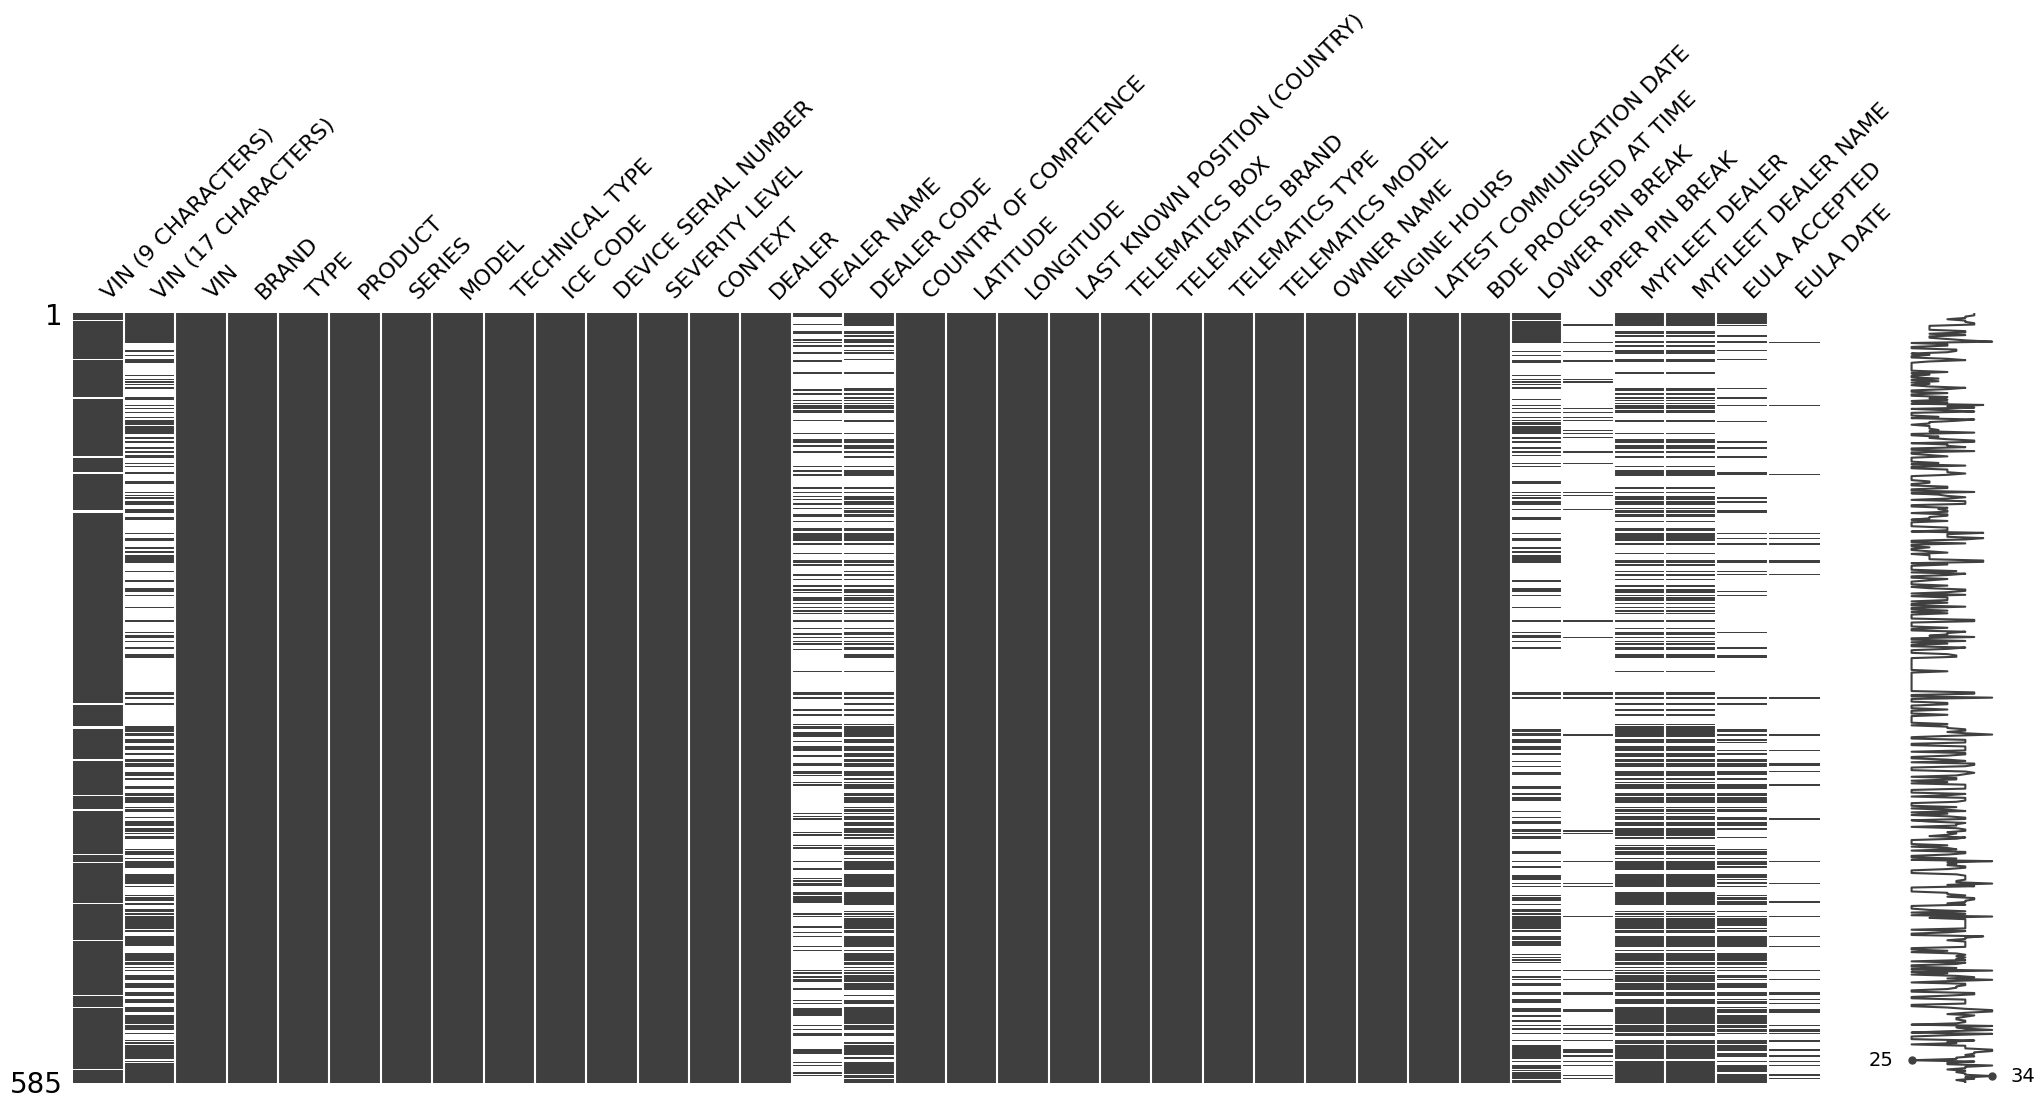

In [ ]:
msno.matrix(PopulationView)

#####**3.1.3.Identificación de Duplicados**

In [ ]:
# Identificación de duplicados
PopulationView_duplicados = PopulationView.duplicated()
PopulationView_duplicados.value_counts()

,count
False,535
True,50


Parece que se tienen 50 datos duplicados

#####**3.1.4.Cantidad de Valores Únicos**

In [ ]:
PopulationView.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
VIN (9 CHARACTERS),516
VIN (17 CHARACTERS),242
VIN,535
BRAND,4
TYPE,5
PRODUCT,13
SERIES,29
MODEL,57
TECHNICAL TYPE,74
ICE CODE,81


#### **3.2 "Horas 2024 y Horas 2025": Exploración General del Data Frame**

#####**3.2.1.Información General**

In [ ]:
Horas2024.info() #Nos permite ver el tipo de dato que tiene cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9405 entries, 0 to 9404
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Num           9405 non-null   int64  
 1   Distribuidor  9405 non-null   object 
 2   IMEI          9405 non-null   int64  
 3   Alias         9405 non-null   object 
 4   Marca         9390 non-null   object 
 5   Modelo        3142 non-null   object 
 6   Ciudad        9390 non-null   object 
 7   Estado        3142 non-null   object 
 8   Latitud       9390 non-null   float64
 9   Longitud      9390 non-null   float64
 10  2024-01       9405 non-null   int64  
 11  2024-02       9405 non-null   int64  
 12  2024-03       9405 non-null   int64  
 13  2024-04       9405 non-null   int64  
 14  2024-05       9405 non-null   int64  
 15  2024-06       9405 non-null   int64  
 16  2024-07       9405 non-null   int64  
 17  2024-08       9405 non-null   int64  
 18  2024-09       9405 non-null 

In [ ]:
Horas2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Num           10157 non-null  int64 
 1   Distribuidor  10157 non-null  object
 2   ID Tractor    10157 non-null  int64 
 3   Alias         10157 non-null  object
 4   2025-01       10157 non-null  int64 
 5   2025-02       10157 non-null  int64 
 6   2025-03       10157 non-null  int64 
 7   2025-04       10157 non-null  int64 
 8   2025-05       10157 non-null  int64 
 9   2025-06       10157 non-null  int64 
 10  2025-07       10157 non-null  int64 
 11  2025-08       10157 non-null  int64 
 12  2025-09       10157 non-null  int64 
 13  2025-10       10157 non-null  int64 
 14  2025-11       10157 non-null  int64 
 15  2025-12       10157 non-null  int64 
dtypes: int64(14), object(2)
memory usage: 1.2+ MB


#####**3.2.2.Identificación de Nulos**

In [ ]:
print("Nulos totales 'Horas 2024':", Horas2024.isnull().sum().sum()) #Nulos totales
Horas2024.isnull().sum() #Nulos por columna

Nulos totales 'Horas 2024': 12586


,0
Num,0
Distribuidor,0
IMEI,0
Alias,0
Marca,15
Modelo,6263
Ciudad,15
Estado,6263
Latitud,15
Longitud,15


In [ ]:
print("Nulos totales 'Horas 2025':", Horas2025.isnull().sum().sum()) #Nulos totales
Horas2025.isnull().sum() #Nulos por columna

Nulos totales 'Horas 2025': 0


,0
Num,0
Distribuidor,0
ID Tractor,0
Alias,0
2025-01,0
2025-02,0
2025-03,0
2025-04,0
2025-05,0
2025-06,0


In [ ]:
# Para saber porcentajes de nulos de cada variable
Horas2024.isnull().sum()/Horas2024.shape[0] * 100

,0
Num,0.000000
Distribuidor,0.000000
IMEI,0.000000
Alias,0.000000
Marca,0.159490
Modelo,66.592238
Ciudad,0.159490
Estado,66.592238
Latitud,0.159490
Longitud,0.159490


In [ ]:
# Para saber porcentajes de nulos de cada variable
Horas2025.isnull().sum()/Horas2025.shape[0] * 100

,0
Num,0.0
Distribuidor,0.0
ID Tractor,0.0
Alias,0.0
2025-01,0.0
2025-02,0.0
2025-03,0.0
2025-04,0.0
2025-05,0.0
2025-06,0.0


######**3.2.2.1.Graficación de Nulos**

<Axes: >

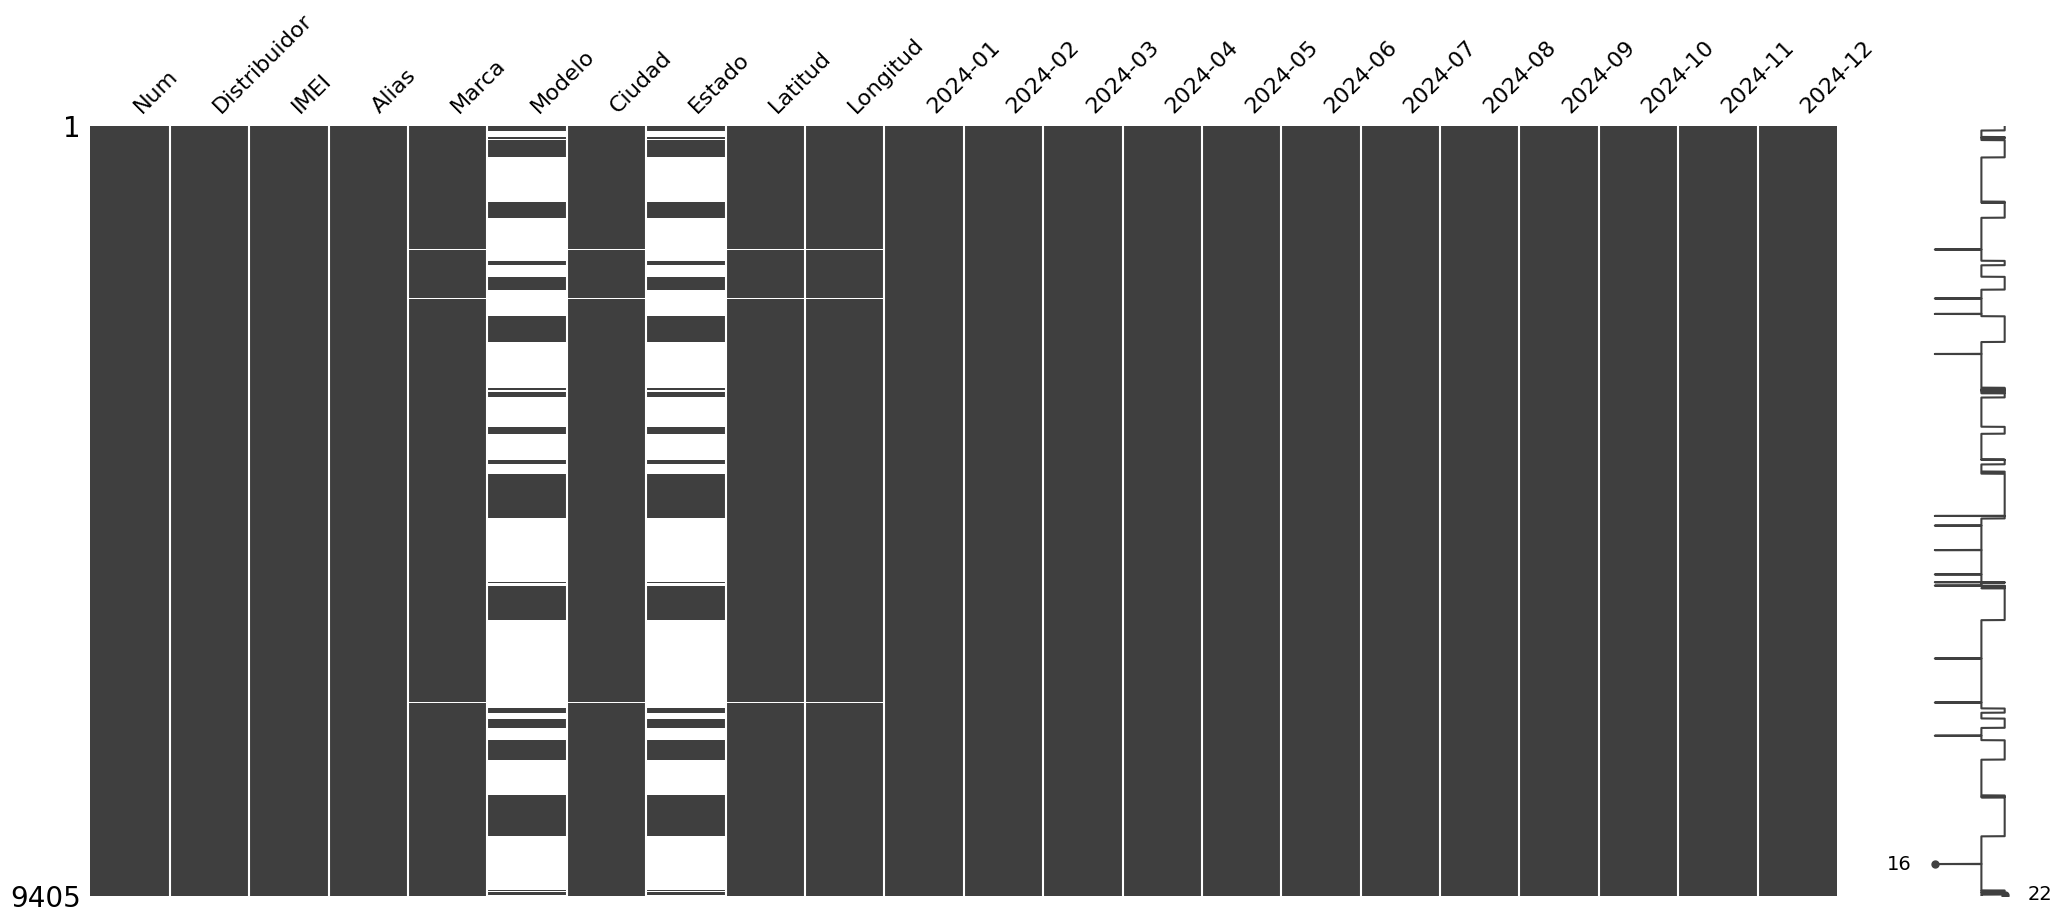

In [ ]:
msno.matrix(Horas2024)

<Axes: >

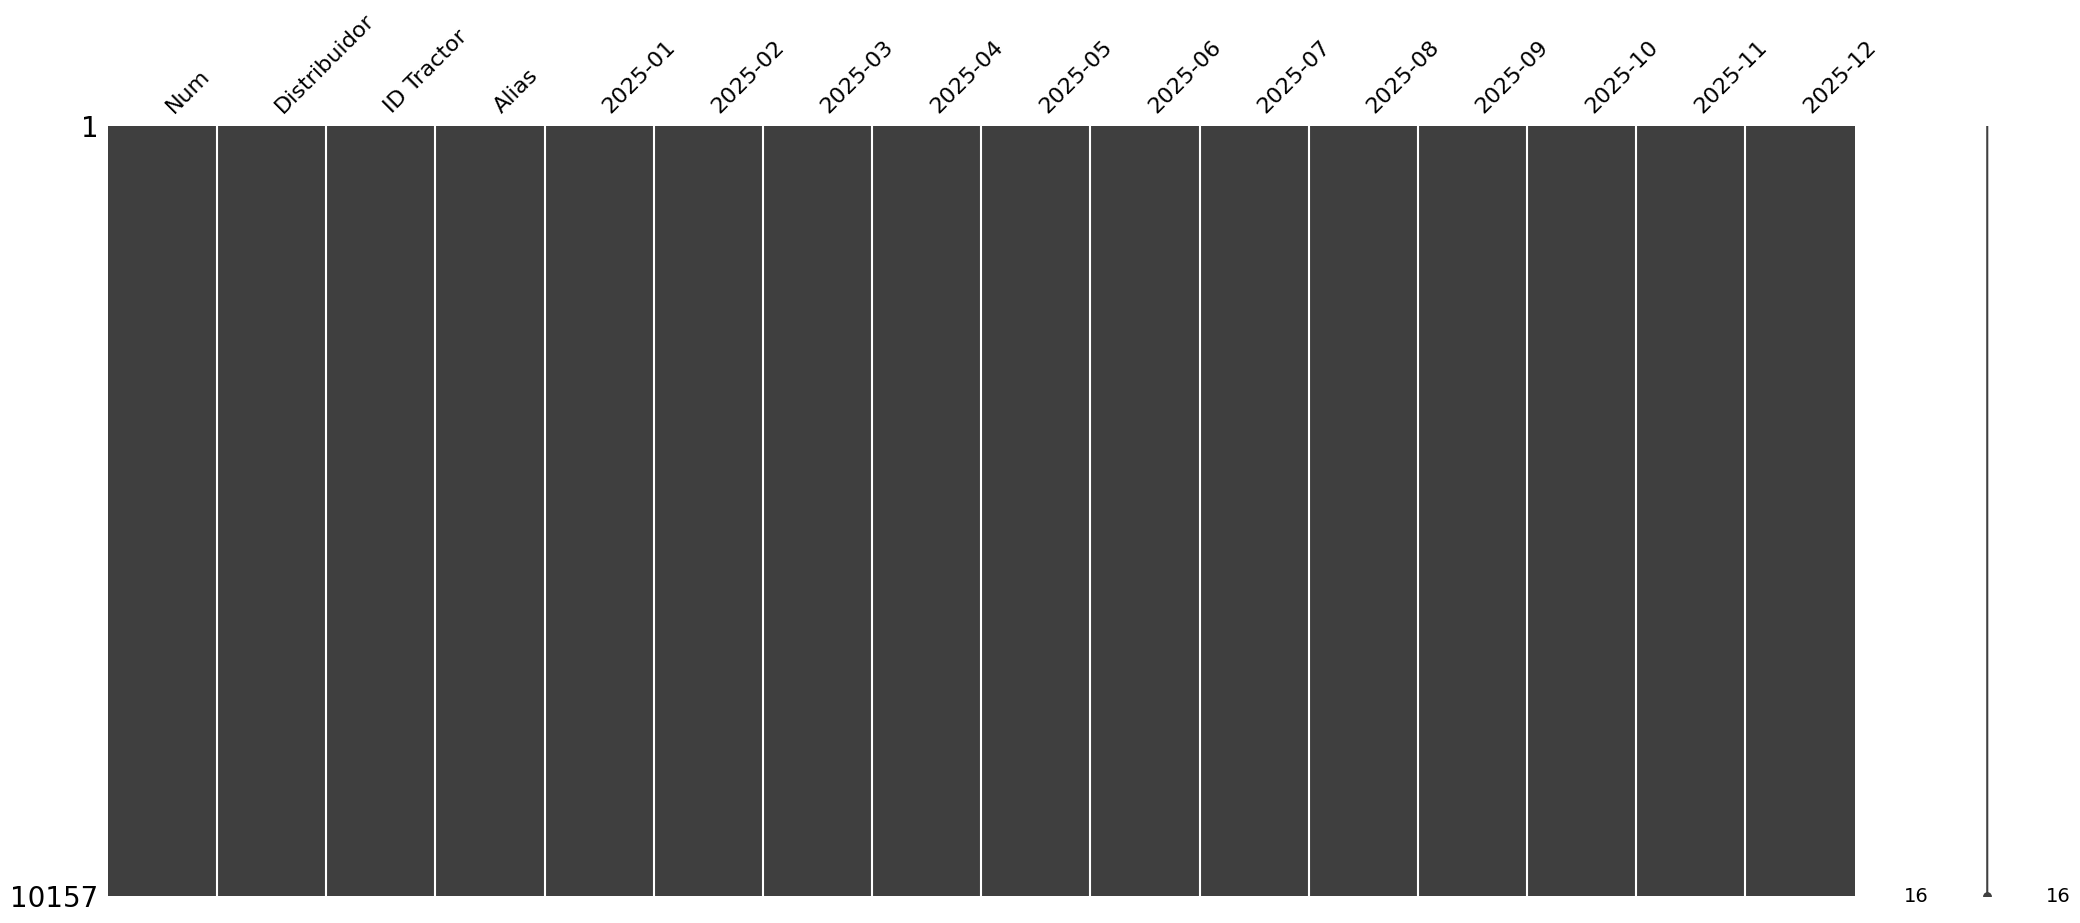

In [ ]:
msno.matrix(Horas2025)

#####**3.2.3.Identificación de Duplicados**

In [ ]:
# Identificación de duplicados 'Horas 2024'
Horas2024_duplicados = Horas2024.duplicated()
Horas2024_duplicados.value_counts()

,count
False,9405


Parece que no hay existencia de datos duplicados

In [ ]:
# Identificación de duplicados 'Horas 2025'
Horas2025_duplicados = Horas2025.duplicated()
Horas2025_duplicados.value_counts()

,count
False,10157


Parece que no hay existencia de datos duplicados

#####**3.2.4.Cantidad de Valores Únicos**

In [ ]:
Horas2024.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
Num,9405
Distribuidor,29
IMEI,8907
Alias,9108
Marca,11
Modelo,63
Ciudad,260
Estado,19
Latitud,8834
Longitud,8835


In [ ]:
Horas2025.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
Num,10157
Distribuidor,30
ID Tractor,9633
Alias,9835
2025-01,268
2025-02,246
2025-03,242
2025-04,257
2025-05,251
2025-06,243


#### **3.3 "Indicadores de Ruteo": Exploración General del Data Frame**

#####**3.3.1.Información General**

In [ ]:
Ruteo.info() #Nos permite ver el tipo de dato que tiene cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Division                        34 non-null     object 
 1   Distancia del Dia               35 non-null     float64
 2   Distancia de Ruta               35 non-null     float64
 3   Cumplimiento Salida (06:30:00)  35 non-null     int64  
 4   % Utilizacion                   35 non-null     int64  
 5   % Visitas Plan                  35 non-null     int64  
 6   % Visitas Clientes              35 non-null     int64  
 7   Total Kilos                     0 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 2.3+ KB


#####**3.3.2.Identificación de Nulos**

In [ ]:
print("Nulos totales: ", Ruteo.isnull().sum().sum()) #Nulos totales
Ruteo.isnull().sum() #Nulos por columna

Nulos totales:  36


,0
Division,1
Distancia del Dia,0
Distancia de Ruta,0
Cumplimiento Salida (06:30:00),0
% Utilizacion,0
% Visitas Plan,0
% Visitas Clientes,0
Total Kilos,35


In [ ]:
# Para saber porcentajes de nulos de cada variable
Ruteo.isnull().sum()/Ruteo.shape[0] * 100

,0
Division,2.857143
Distancia del Dia,0.000000
Distancia de Ruta,0.000000
Cumplimiento Salida (06:30:00),0.000000
% Utilizacion,0.000000
% Visitas Plan,0.000000
% Visitas Clientes,0.000000
Total Kilos,100.000000


######**3.3.2.1.Graficación de Nulos**

<Axes: >

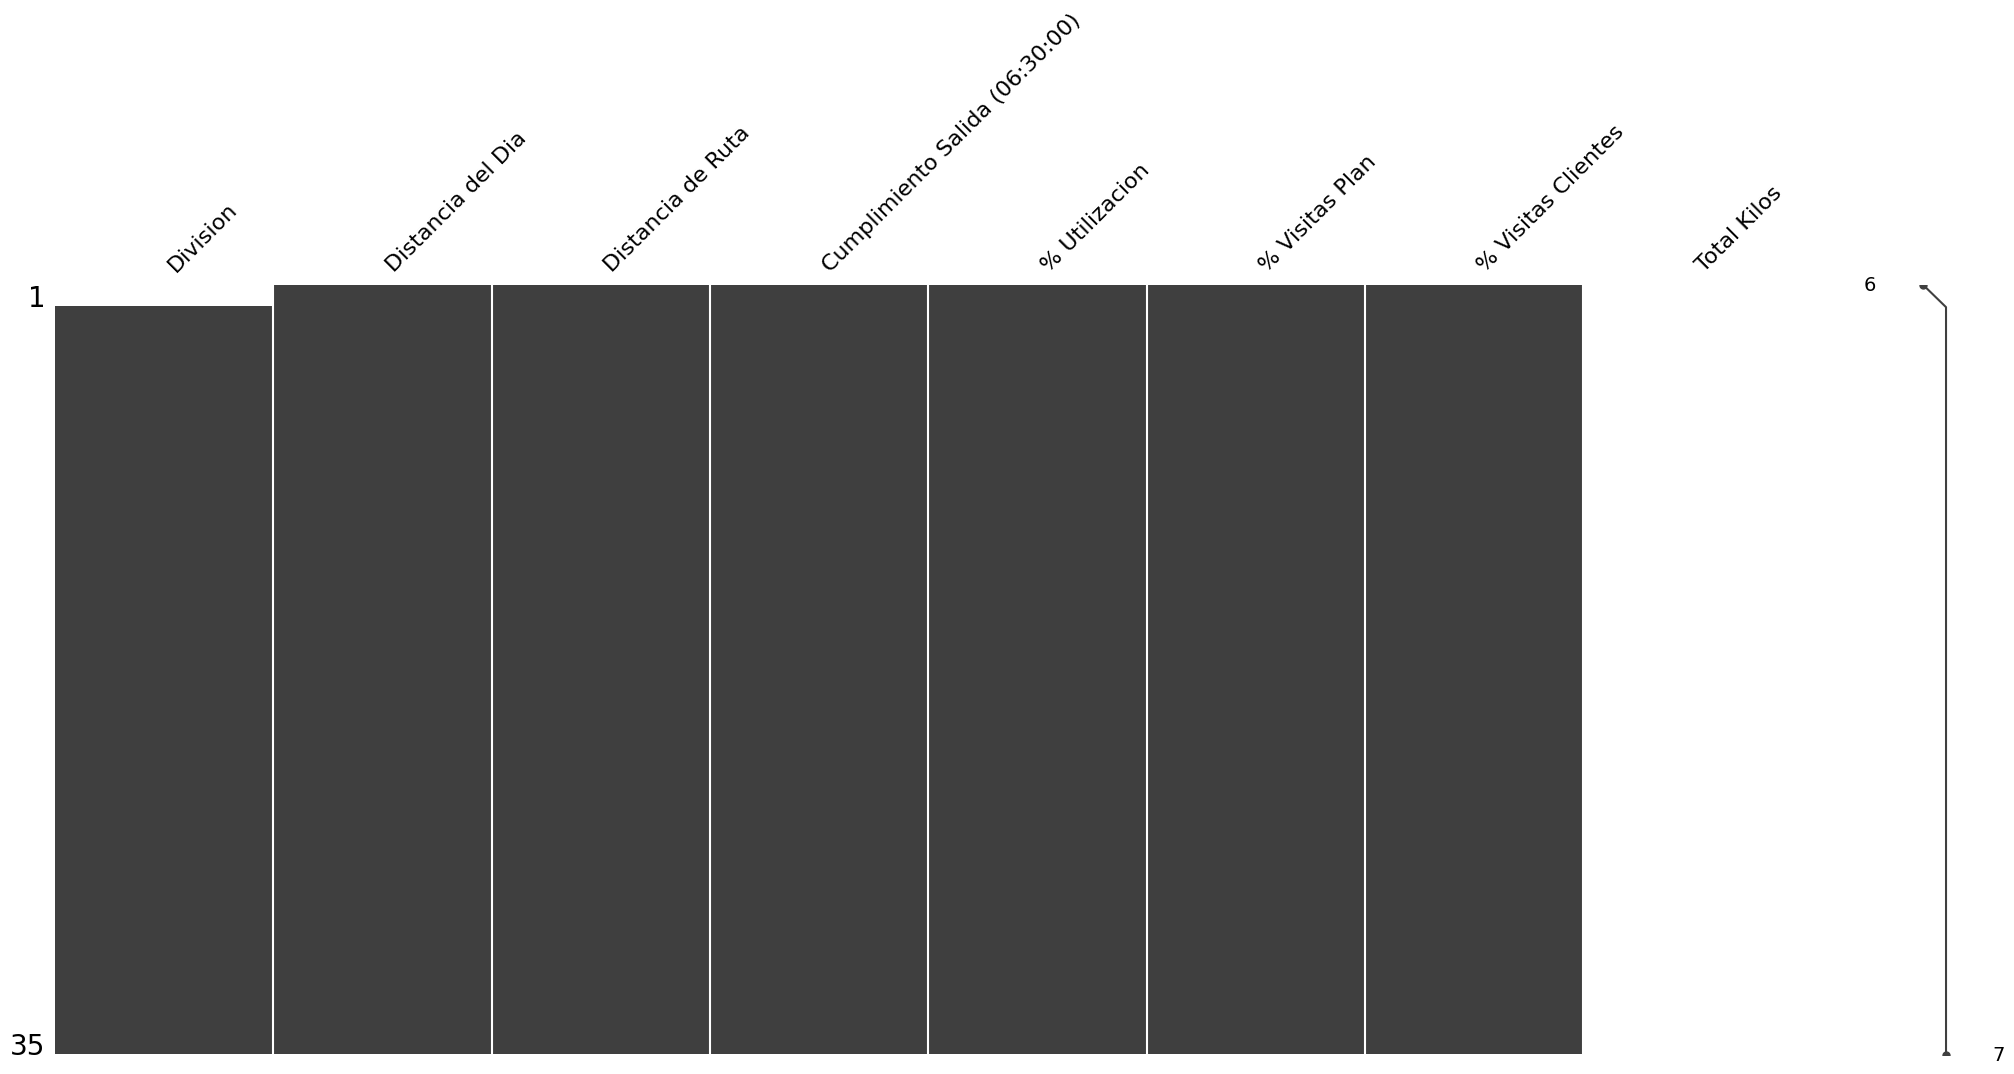

In [ ]:
msno.matrix(Ruteo)

#####**3.3.3.Identificación de Duplicados**

In [ ]:
# Identificación de duplicados
Ruteo_duplicados = Ruteo.duplicated()
Ruteo_duplicados.value_counts()

,count
False,35


Parece que no hay existencia de datos duplicados

#####**3.3.4.Cantidad de Valores Únicos**

In [ ]:
Ruteo.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
Division,34
Distancia del Dia,35
Distancia de Ruta,35
Cumplimiento Salida (06:30:00),1
% Utilizacion,1
% Visitas Plan,1
% Visitas Clientes,1
Total Kilos,0


#### **3.4 "Mantenimientos 2024-2025": Exploración General del Data Frame**

#####**3.4.1.Información General**

In [ ]:
Mantenimientos.info() #Nos permite ver el tipo de dato que tiene cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23904 entries, 0 to 23903
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   No             0 non-null      float64
 1   ALIAS          23904 non-null  object 
 2   MARCA          23900 non-null  object 
 3   MODELO         23900 non-null  object 
 4   CONFIGURACION  23900 non-null  object 
 5   NO SERIE       23866 non-null  object 
 6   DISTRIBUIDOR   23601 non-null  object 
 7   SERVICIO       23904 non-null  int64  
 8   HRMTRO         23904 non-null  float64
 9   ACTUAL         23904 non-null  int64  
 10  TIPO           23900 non-null  object 
 11  FECHA          23904 non-null  object 
 12  O.T.           9484 non-null   object 
 13  ESTATUS        23900 non-null  object 
 14  Editar         0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 2.7+ MB


#####**3.4.2.Identificación de Nulos**

In [ ]:
print("Nulos totales: ", Mantenimientos.isnull().sum().sum()) #Nulos totales
Mantenimientos.isnull().sum() #Nulos por columna

Nulos totales:  62589


,0
No,23904
ALIAS,0
MARCA,4
MODELO,4
CONFIGURACION,4
NO SERIE,38
DISTRIBUIDOR,303
SERVICIO,0
HRMTRO,0
ACTUAL,0


In [ ]:
# Para saber porcentajes de nulos de cada variable
Mantenimientos.isnull().sum()/Mantenimientos.shape[0] * 100

,0
No,100.000000
ALIAS,0.000000
MARCA,0.016734
MODELO,0.016734
CONFIGURACION,0.016734
NO SERIE,0.158969
DISTRIBUIDOR,1.267570
SERVICIO,0.000000
HRMTRO,0.000000
ACTUAL,0.000000


######**3.4.2.1.Graficación de Nulos**

<Axes: >

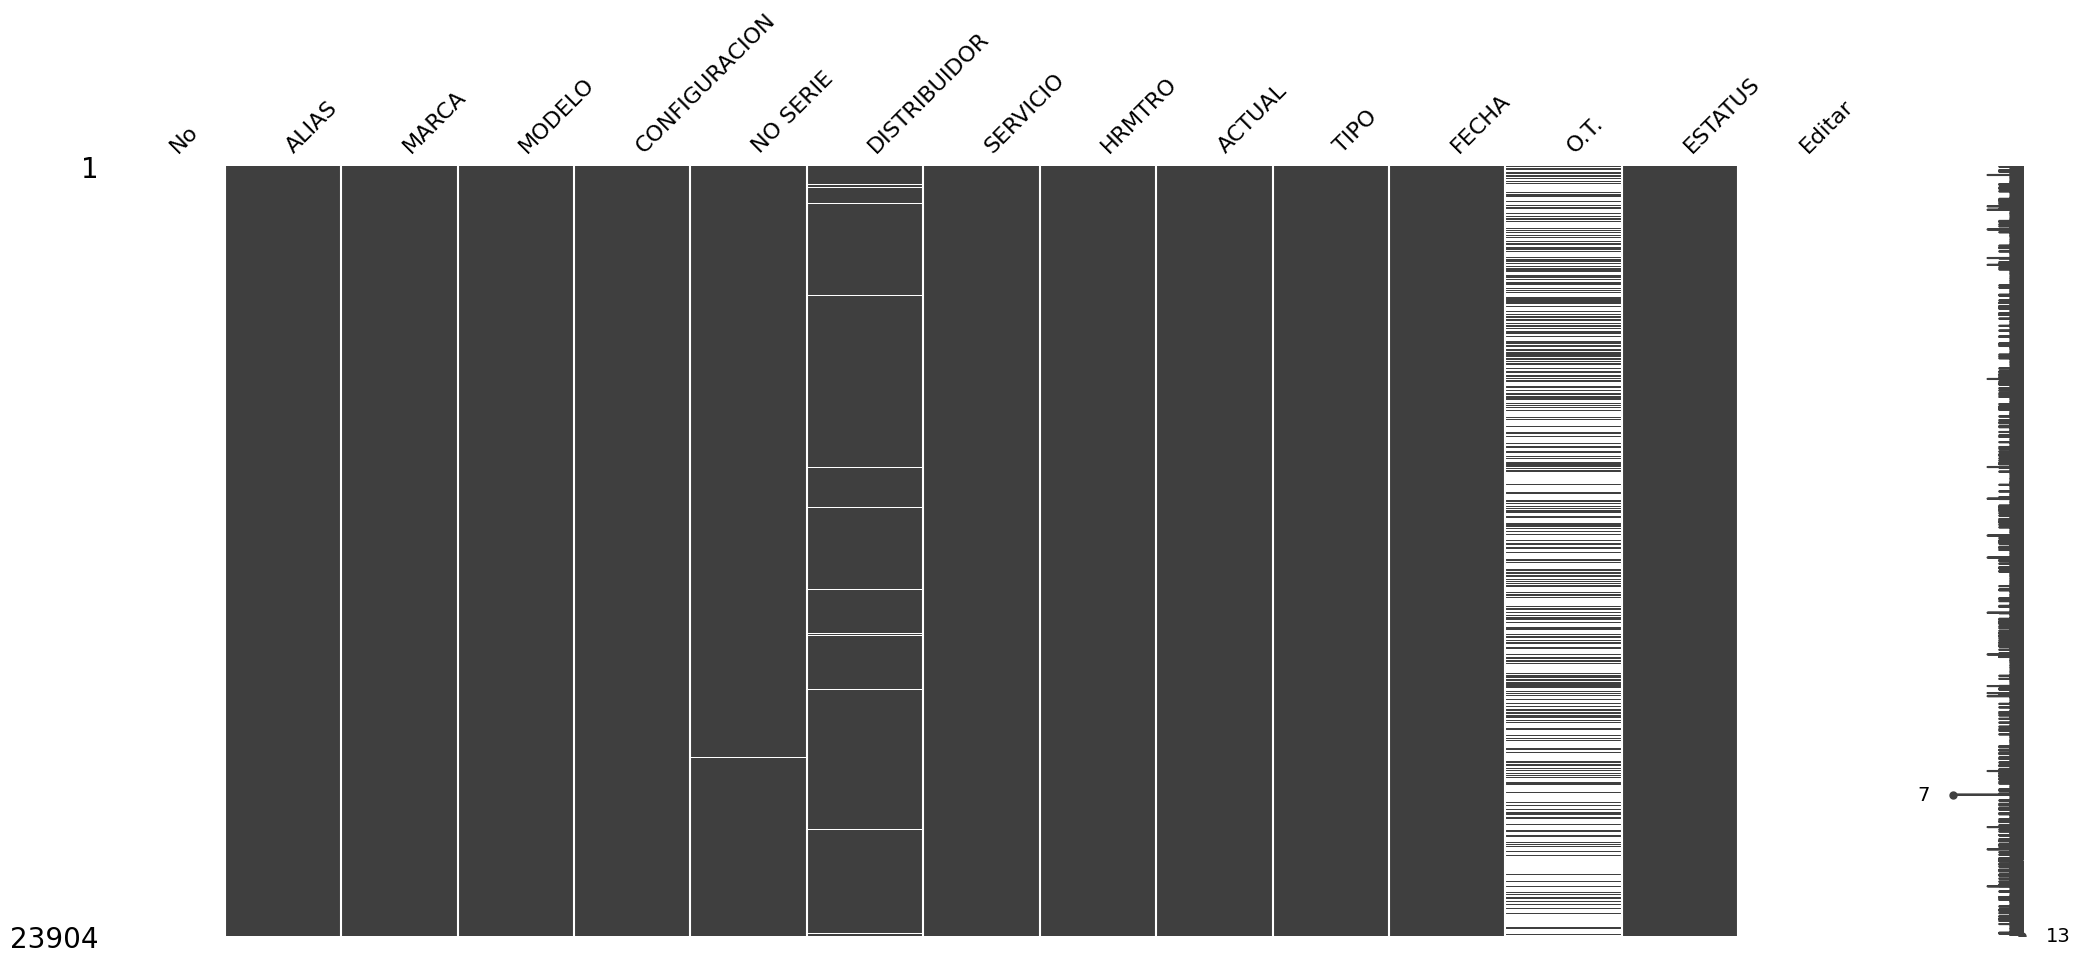

In [ ]:
msno.matrix(Mantenimientos)

#####**3.4.3.Identificación de Duplicados**

In [ ]:
# Identificación de duplicados
Mantenimientos_duplicados = Mantenimientos.duplicated()
Mantenimientos_duplicados.value_counts()

,count
False,23869
True,35


Parece que se tienen 35 datos duplicados

#####**3.4.4.Identificación de Valores Únicos**

In [ ]:
Mantenimientos.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
No,0
ALIAS,6775
MARCA,4
MODELO,23
CONFIGURACION,24
NO SERIE,6763
DISTRIBUIDOR,32
SERVICIO,45
HRMTRO,3385
ACTUAL,3103


Esto permite ver que, se tiene el registro de que 6,775 unidades que han recibido mantenimientos, ya que con la columna 'ALIAS' se puede identificar que los valores únicos que le corresponden, se refieren a cada unidad (tractor) como individual

#### **3.5 "Reporte unidades día anterior": Exploración General del Data Frame**

#####**3.5.1.Información General**

In [ ]:
UnidadesDA.info() #Nos permite ver el tipo de dato que tiene cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   No                   10846 non-null  int64         
 1   IMEI                 10846 non-null  object        
 2   Alias                10846 non-null  object        
 3   Marca                10129 non-null  object        
 4   Modelo               9907 non-null   object        
 5   Configuracion        9430 non-null   object        
 6   Fecha Alta           10204 non-null  datetime64[ns]
 7   No. Serie            10136 non-null  object        
 8   Distribuidor         9643 non-null   object        
 9   Ciudad               9643 non-null   object        
 10  Estado               9643 non-null   object        
 11  Horometro            10846 non-null  float64       
 12  Odometro             10846 non-null  float64       
 13  Total                10846 non-

#####**3.5.2.Identificación de Nulos**

In [ ]:
print("Nulos totales: ", UnidadesDA.isnull().sum().sum()) #Nulos totales
UnidadesDA.isnull().sum() #Nulos por columna

Nulos totales:  116124


,0
No,0
IMEI,0
Alias,0
Marca,717
Modelo,939
Configuracion,1416
Fecha Alta,642
No. Serie,710
Distribuidor,1203
Ciudad,1203


In [ ]:
# Para saber porcentajes de nulos de cada variable
UnidadesDA.isnull().sum()/UnidadesDA.shape[0] * 100

,0
No,0.000000
IMEI,0.000000
Alias,0.000000
Marca,6.610732
Modelo,8.657570
Configuracion,13.055504
Fecha Alta,5.919233
No. Serie,6.546192
Distribuidor,11.091647
Ciudad,11.091647


######**3.5.2.1.Graficación de Nulos**

<Axes: >

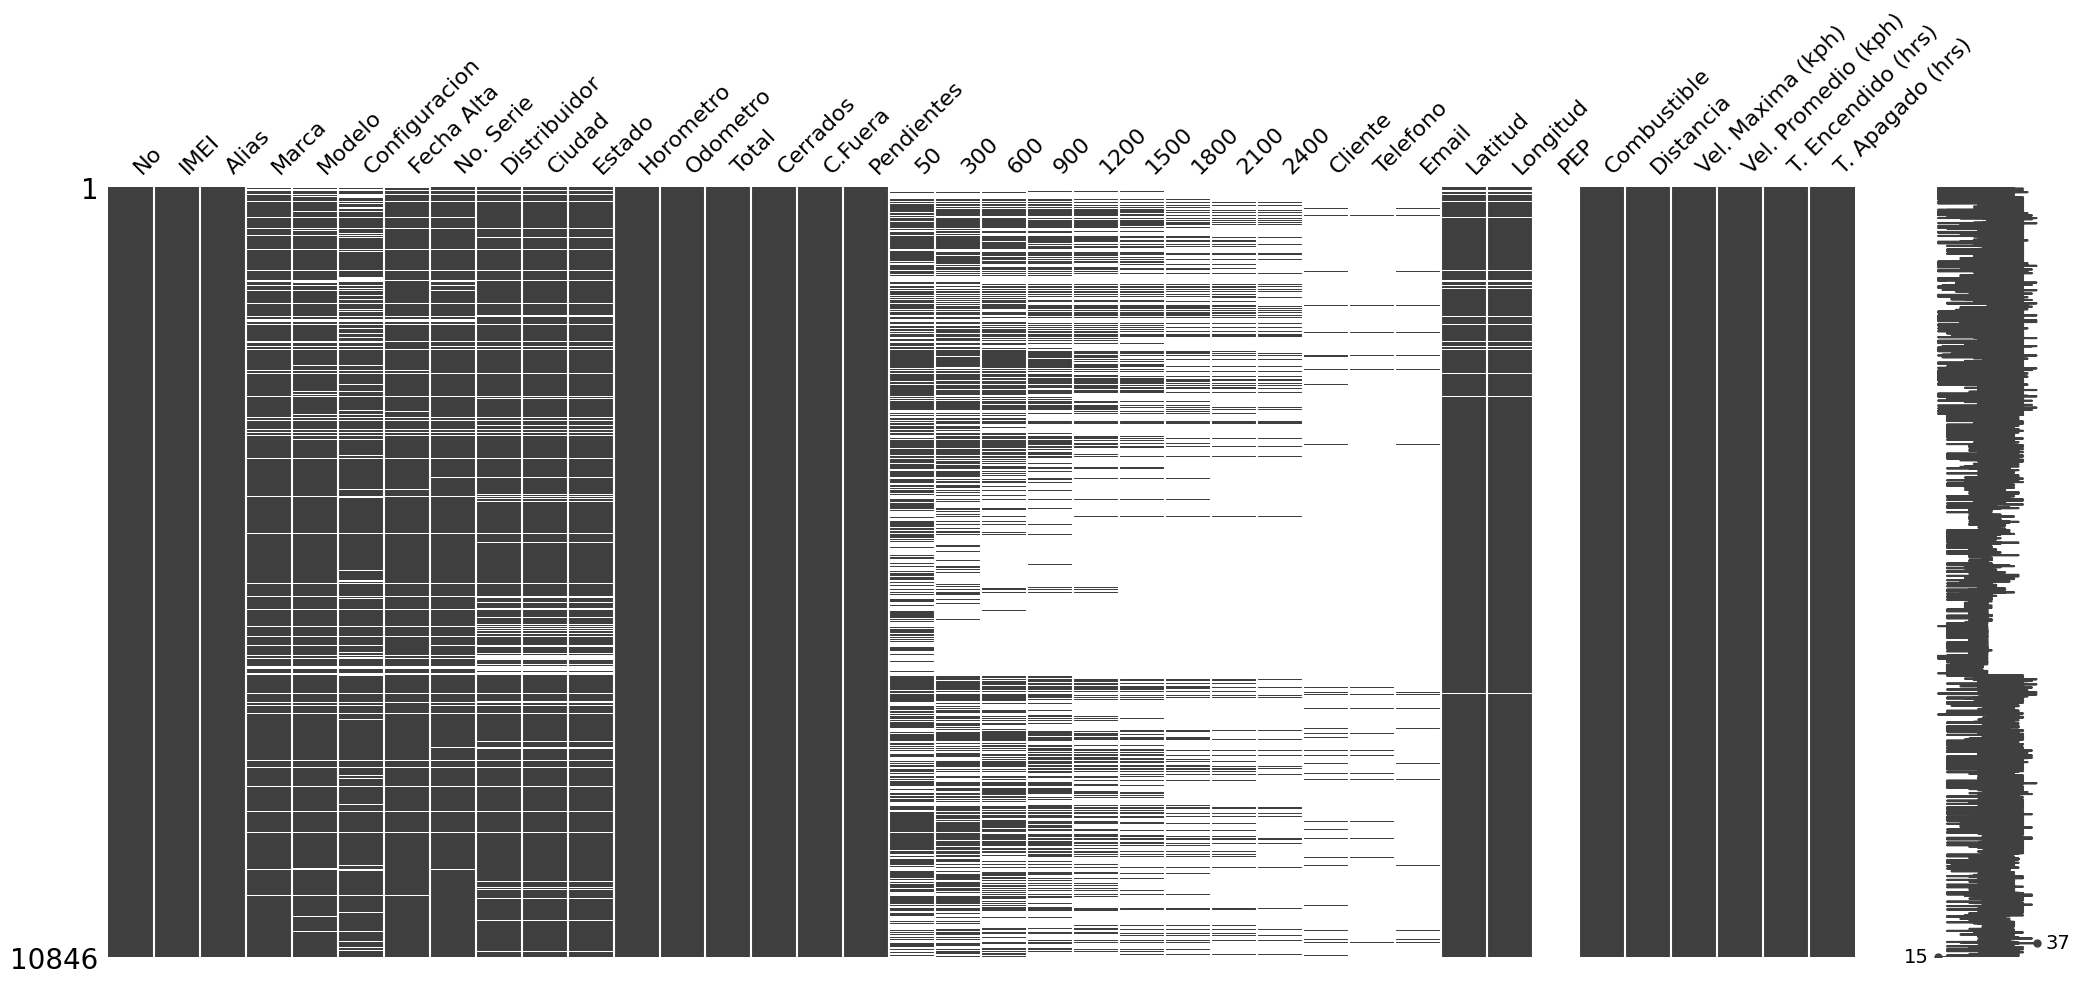

In [ ]:
msno.matrix(UnidadesDA)

#####**3.5.3.Identificación de Duplicados**

In [ ]:
# Identificación de duplicados
UnidadesDA_duplicados = UnidadesDA.duplicated()
UnidadesDA_duplicados.value_counts()

,count
False,10846


Parece que no hay existencia de datos duplicados

#####**3.5.4.Identificación de Valores Únicos**

In [ ]:
UnidadesDA.nunique() #Nos permite ver la cantidad de valores unicos que tiene cada columna

,0
No,10846
IMEI,10846
Alias,10844
Marca,10
Modelo,84
Configuracion,41
Fecha Alta,899
No. Serie,10106
Distribuidor,35
Ciudad,627


## **4.Perfiles involucrados en la gestón y mantenimiento de los datos**

Actualmente, las únicas 2 personas que se encargan de ver la información y realmente la gestión, son José Bravo como el principal encargado del area de aftermarket en la sucursal de Querétaro de CNH, y Ricardo Valenzo, un becario de CNH que se encarga de llevar una comunicación más dinámica entre CNH y los equipos del reto. Ellos son los que se encargan del mantenimiento de los datos y son los únicos administradores de las bases de datos, donde Ricardo generó los diccionarios para proporcionarlos a nosotros.

## **5.Renombre de columnas e índices y Conversiones de tipos de datos**

Renombrar las columnas e índices para que sean representativos de la información que almacenan. Así mismo, hagan las conversiones de tipos de datos requeridas y justifiquen su selección.

**Etapa de Limpieza y Tipado de Datos**

En esta etapa se realizó la limpieza profunda y el tipado de los seis conjuntos de datos para asegurar la integridad de la información y facilitar los cruces posteriores.

---

**1. Normalización de Nombres (Renombre)**

Para evitar errores de sintaxis y facilitar el llamado de variables, se aplicó una función de estandarización y renombres manuales:

* **Limpieza Automática:**  
Se utilizó una función para convertir títulos a minúsculas, reemplazar espacios por guiones bajos (`_`) y eliminar caracteres especiales mediante `regex`.

* **Identificadores Únicos:**  
Se unificaron las columnas de series, bajo el nombre `numero_serie` en todas las tablas para permitir el linkeo en pasos posteriores.

* **Métricas de Ruteo:**  
Se renombraron indicadores específicos, destacando:
  * `cumplimiento_salida_(06:30:00)` *(manteniendo la referencia horaria solicitada)*  
  * Uso del prefijo `porc_` para porcentajes *(ej. `porc_utilizacion`)*

* **Columnas Dinámicas:**  
  * En las tablas de Horas, los meses se transformaron al formato `hrs_2024_01`  
  * En el Reporte de Unidades, los umbrales de mantenimiento se transformaron al formato `mant_50`, `mant_300`, etc.

* **Correcciones Específicas:**  
Se ajustó `cfuera` a `c_fuera` y se renombró `ot` a `orden_trabajo`.

---

**2. Conversión de Tipos de Datos (Casting)**

Se ajustaron los tipos de datos para permitir cálculos matemáticos y optimizar el uso de memoria RAM:

* **Fechas (`datetime`):**  
Se convirtieron columnas como `fecha_alta`, `fecha_ultima_comunicacion` y `fecha` para permitir análisis temporales.

* **Numéricos (`float64` / `int64`):**  
Se forzó la conversión a número en columnas de:
  * `horometro`, `odometro`, `latitud` y `longitud`  
  * Velocidades (`vel_maxima_kph`, `vel_promedio_kph`)  
  * Tiempos de uso y todas las columnas con prefijos `hrs_` y `mant_`

* **Categorías (`category`):**  
Las variables de texto repetitivo como `marca`, `modelo`, `distribuidor` y `estado` se convirtieron a tipo categórico para mejorar el rendimiento del sistema.

---

**3. Verificación de Resultados**

Se habilitó la visualización de los `DataFrames` completos para validar que la estructura final coincida **1:1** con el archivo de control de renombre de columnas e índices.

In [ ]:
# ------------------------------------------------------------------------------
# 1. RENOMBRAR COLUMNAS
# ------------------------------------------------------------------------------

def estandarizar_columnas(df):
    df.columns = (df.columns.str.strip()
                            .str.lower()
                            .str.replace(' ', '_', regex=False)
                            .str.replace(r'[^\w_]', '', regex=True))

dataframes = [PopulationView, Horas2024, Horas2025, Ruteo, Mantenimientos, UnidadesDA]
for df in dataframes:
    estandarizar_columnas(df)

# 1.1 HORAS (Lógica para meses hrs_2024_01)
for df in [Horas2024, Horas2025]:
    renombres_meses = {col: f"hrs_{col[:4]}_{col[4:]}" for col in df.columns if col.startswith('202')}
    df.rename(columns=renombres_meses, inplace=True)

# 1.2 INDICADORES DE RUTEO
Ruteo.rename(columns={
    'cumplimiento_salida_063000': 'cumplimiento_salida_(06:30:00)',
    '_utilizacion': 'porc_utilizacion',
    '_visitas_plan': 'porc_visitas_plan',
    '_visitas_clientes': 'porc_visitas_clientes'
}, inplace=True)

# 1.3 MANTENIMIENTOS 2024-2025
Mantenimientos.rename(columns={
    'hrmtro': 'horometro',
    'ot': 'orden_trabajo'
}, inplace=True)

# 1.4 UNIDADES DÍA ANTERIOR
UnidadesDA.rename(columns={
    'cfuera': 'c_fuera'
}, inplace=True)

# 1.5 RENOMBRAR COLUMNAS DE MANTENIMIENTO EN UnidadesDA (ej. 50 -> mant_50)
renombres_mant = {col: f"mant_{col}" for col in UnidadesDA.columns if isinstance(col, str) and col.isdigit()}
UnidadesDA.rename(columns=renombres_mant, inplace=True)


# ------------------------------------------------------------------------------
# 2. CONVERSIONES DE TIPOS DE DATOS (CASTING)
# ------------------------------------------------------------------------------

# A. Población (Population View)
PopulationView['latest_communication_date'] = pd.to_datetime(PopulationView['latest_communication_date'], errors='coerce')
PopulationView['engine_hours'] = pd.to_numeric(PopulationView['engine_hours'], errors='coerce')

for col in ['marca', 'type', 'product', 'dealer', 'series', 'model']:
    if col in PopulationView.columns:
        PopulationView[col] = PopulationView[col].astype('category')

# B. Horas 2024 y 2025
for df in [Horas2024, Horas2025]:
    cols_hrs = [c for c in df.columns if 'hrs_' in c]
    df[cols_hrs] = df[cols_hrs].apply(pd.to_numeric, errors='coerce')

    for cat_col in ['marca', 'modelo', 'estado', 'distribuidor', 'ciudad']:
        if cat_col in df.columns:
            df[cat_col] = df[cat_col].astype('category')

# C. Mantenimientos
Mantenimientos['fecha'] = pd.to_datetime(Mantenimientos['fecha'], errors='coerce')
Mantenimientos[['horometro', 'actual']] = Mantenimientos[['horometro', 'actual']].apply(pd.to_numeric, errors='coerce')

for col in ['marca', 'modelo', 'tipo', 'estatus', 'servicio', 'distribuidor']:
    if col in Mantenimientos.columns:
        Mantenimientos[col] = Mantenimientos[col].astype('category')

# D. Reporte de unidades diarias
UnidadesDA['fecha_alta'] = pd.to_datetime(UnidadesDA['fecha_alta'], errors='coerce')

cols_num_da = [
    'horometro', 'odometro', 'latitud', 'longitud',
    'vel_maxima_kph', 'vel_promedio_kph',
    'tiempo_encendido_hrs', 'tiempo_apagado_hrs', 'c_fuera'
]
cols_mant_da = [c for c in UnidadesDA.columns if isinstance(c, str) and 'mant_' in c]

for col in (cols_num_da + cols_mant_da):
    if col in UnidadesDA.columns:
        UnidadesDA[col] = pd.to_numeric(UnidadesDA[col], errors='coerce')

for col in ['marca', 'modelo', 'configuracion', 'distribuidor', 'ciudad', 'estado', 'cliente']:
    if col in UnidadesDA.columns:
        UnidadesDA[col] = UnidadesDA[col].astype('category')

## **5.1 Renombramiento de columnas**


### **5.1.1 "Archivo: Population View"**

| # | Nombre Original | Renombre |
|---|----------------|----------|
| 1 | VIN (9 CHARACTERS) | vin_9_characters |
| 2 | VIN (17 CHARACTERS) | vin_17_characters |
| 3 | VIN | vin |
| 4 | BRAND | brand |
| 5 | TYPE | type |
| 6 | PRODUCT | product |
| 7 | SERIES | series |
| 8 | MODEL | model |
| 9 | TECHNICAL TYPE | technical_type |
| 10 | ICE CODE | ice_code |
| 11 | DEVICE SERIAL NUMBER | device_serial_number |
| 12 | SEVERITY LEVEL | severity_level |
| 13 | CONTEXT | context |
| 14 | DEALER | dealer |
| 15 | DEALER NAME | dealer_name |
| 16 | DEALER CODE | dealer_code |
| 17 | COUNTRY OF COMPETENCE | country_of_competence |
| 18 | LATITUDE | latitude |
| 19 | LONGITUDE | longitude |
| 20 | LAST KNOWN POSITION (COUNTRY) | last_known_position_country |
| 21 | TELEMATICS BOX | telematics_box |
| 22 | TELEMATICS BRAND | telematics_brand |
| 23 | TELEMATICS TYPE | telematics_type |
| 24 | TELEMATICS MODEL | telematics_model |
| 25 | OWNER NAME | owner_name |
| 26 | ENGINE HOURS | horas_motor |
| 27 | LATEST COMMUNICATION DATE | latest_communication_date |
| 28 | BDE PROCESSED AT TIME | bde_processed_at_time |
| 29 | LOWER PIN BREAK | lower_pin_break |
| 30 | UPPER PIN BREAK | upper_pin_break |
| 31 | MYFLEET DEALER | myfleet_dealer |
| 32 | MYFLEET DEALER NAME | myfleet_dealer_name |
| 33 | EULA ACCEPTED | eula_accepted |
| 34 | EULA DATE | eula_date |

### **5.1.2 "Archivo: Horas 2024-2025"**

| # | Nombre Original | Renombre |
|---|----------------|----------|
| 1 | Num | num |
| 2 | Distribuidor | distribuidor |
| 3 | IMEI | imei |
| 4 | Alias | alias |
| 5 | Marca | marca |
| 6 | Modelo | modelo |
| 7 | Ciudad | ciudad |
| 8 | Estado | estado |
| 9 | Latitud | latitud |
| 10 | Longitud | longitud |
| 11 | 2024-01 | hrs_2024_01 |
| 12 | 2024-02 | hrs_2024_02 |
| 13 | 2024-05 | hrs_2024_05 |
| 14 | 2024-06 | hrs_2024_06 |
| 15 | 2024-07 | hrs_2024_07 |
| 16 | 2024-08 | hrs_2024_08 |
| 17 | 2024-09 | hrs_2024_09 |
| 18 | 2024-10 | hrs_2024_10 |
| 19 | 2024-11 | hrs_2024_11 |
| 20 | 2024-12 | hrs_2024_12 |

### **5.1.3 "Archivo: Indicadores de Ruteo"**

| # | Nombre Original | Renombre |
|---|----------------|----------|
| 1 | Division | division |
| 2 | Distancia del Dia | distancia_del_dia |
| 3 | Distancia de Ruta | distancia_de_ruta |
| 4 | Cumplimiento Salida (06:30:00) | cumplimiento_salida_0630 |
| 5 | % Utilizacion | porc_utilizacion |
| 6 | % Visitas Plan | porc_visitas_plan |
| 7 | % Visitas Clientes | porc_visitas_clientes |
| 8 | Total Kilos | total_kilos |

### **5.1.4 "Archivo: Mantenimientos 2024-2025"**

| # | Nombre Original | Renombre |
|---|----------------|----------|
| 1 | No | no |
| 2 | ALIAS | alias |
| 3 | MARCA | marca |
| 4 | MODELO | modelo |
| 5 | CONFIGURACION | configuracion |
| 6 | NO SERIE | no_serie |
| 7 | DISTRIBUIDOR | distribuidor |
| 8 | SERVICIO | servicio |
| 9 | HRMTRO | horometro |
| 10 | ACTUAL | actual |
| 11 | TIPO | tipo |
| 12 | FECHA | fecha |
| 13 | O.T. | orden_trabajo |
| 14 | ESTATUS | estatus |
| 15 | Editar | editar |

### **5.1.5 "Archivo: Reporte Unidades Día Anterior"**

| # | Nombre Original | Renombre |
|---|----------------|----------|
| 1 | No | no |
| 2 | IMEI | imei |
| 3 | Alias | alias |
| 4 | Marca | marca |
| 5 | Modelo | modelo |
| 6 | Configuracion | configuracion |
| 7 | Fecha Alta | fecha_alta |
| 8 | No. Serie | no_serie |
| 9 | Distribuidor | distribuidor |
| 10 | Ciudad | ciudad |
| 11 | Estado | estado |
| 12 | Horometro | horometro |
| 13 | Odometro | odometro |
| 14 | Total | total |
| 15 | Cerrados | cerrados |
| 16 | C.Fuera | c_fuera |
| 17 | Pendientes | pendientes |
| 18 | 50 | mant_50 |
| 19 | 300 | mant_300 |
| 20 | 600 | mant_600 |
| 21 | 900 | mant_900 |
| 22 | 1200 | mant_1200 |
| 23 | 1500 | mant_1500 |
| 24 | 1800 | mant_1800 |
| 25 | 2100 | mant_2100 |
| 26 | 2400 | mant_2400 |
| 27 | Cliente | cliente |
| 28 | Telefono | telefono |
| 29 | Email | email |
| 30 | Latitud | latitud |
| 31 | Longitud | longitud |
| 32 | PEP | pep |
| 33 | Combustible | combustible |
| 34 | Distancia | distancia |
| 35 | Vel. Maxima (kph) | vel_maxima_kph |
| 36 | Vel. Promedio (kph) | vel_promedio_kph |
| 37 | T. Encendido (hrs) | t_encendido_hrs |
| 38 | T. Apagado (hrs) | t_apagado_hrs |

In [ ]:
# ------------------------------------------------------------------------------
# 3. VERIFICACIÓN DE RESULTADOS (DATAFRAMES COMPLETOS)
# ------------------------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


def mostrar_df(nombre, df):
    """
    Imprime un encabezado estético y renderiza el DataFrame completo.
    Utiliza display() para aprovechar la interfaz interactiva de Colab.
    """
    print("\n" + "="*50)
    print(f" DATAFRAME: {nombre}")
    print(f" DIMENSIONES: {df.shape[0]} filas x {df.shape[1]} columnas")
    print("="*50)
    display(df)

# Ejecución de la muestra para los 6 archivos procesados
mostrar_df("1. POPULATION VIEW", PopulationView)
mostrar_df("2. HORAS 2024", Horas2024)
mostrar_df("3. HORAS 2025", Horas2025)
mostrar_df("4. INDICADORES DE RUTEO", Ruteo)
mostrar_df("5. MANTENIMIENTOS 2024-2025", Mantenimientos)
mostrar_df("6. REPORTE UNIDADES DÍA ANTERIOR", UnidadesDA)


 DATAFRAME: 1. POPULATION VIEW
 DIMENSIONES: 585 filas x 34 columnas


,vin_9_characters,vin_17_characters,vin,brand,type,product,series,model,technical_type,ice_code,device_serial_number,severity_level,context,dealer,dealer_name,dealer_code,country_of_competence,latitude,longitude,last_known_position_country,telematics_box,telematics_brand,telematics_type,telematics_model,owner_name,engine_hours,latest_communication_date,bde_processed_at_time,lower_pin_break,upper_pin_break,myfleet_dealer,myfleet_dealer_name,eula_accepted,eula_date
0,NPC787370,JJGN58NRPPC787370,JJGN58NRPPC787370,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717750,E.S.65.004.001.053,1598-3C000B20,Low,CNH_CE,Yes,"Maquirent Oaxaca, Sa De Cv",190-08B215,Mexico,16.546654,-95.957832,Mexico,CM1X,CC,TLB_US,580N (T3),"Maquirent Oaxaca, Sa De Cv",0,2023-08-28 17:10:42,2026-02-09 00:33:33,NNC779550,NaN,190-08B215A,"Maquirent Oaxaca, Sa De Cv",Yes,NaT
1,NPC781693,JJGN58SRAPC781693,JJGN58SRAPC781693,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580SN,675727750,E.S.65.004.002.040,1598-3C000A71,Low,CNH_CE,Yes,Distribuidora Cummins De Baja Sderl Decv,190-08B064,Mexico,20.637114,-100.429787,Mexico,CM1X,CC,TLB_US,580SN (T3),Distribuidora Cummins De Baja Sderl Decv,2,2023-09-14 15:43:16,2026-02-09 00:33:33,NNC781526,NaN,190-08B064A,Distribuidora Cummins De Baja Sderl Decv,Yes,NaT
2,NPC781693,JJGN58SRAPC781693,JJGN58SRAPC781693,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580SN,675727750,E.S.65.004.002.040,1598-3C000A71,Low,CNH_CE,Yes,Distribuidora Cummins De Baja Sderl Decv,190-08B064,Mexico,20.637114,-100.429787,Mexico,CM1X,CC,TLB_US,580SN (T3),Distribuidora Cummins De Baja Sderl Decv,2,2023-09-14 15:43:16,2026-02-09 00:33:33,NNC781526,NaN,190-08B064A,Distribuidora Cummins De Baja Sderl Decv,Yes,NaT
3,NPC787410,JJGN58NRVPC787410,JJGN58NRVPC787410,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,1598-3C000A8A,Low,CNH_CE,No,NaN,190-08B272,Mexico,28.698889,-100.514816,Mexico,CM1X,CC,TLB_US,580N (T3),CONSTRUCCIONES INSTALACIONES Y ASESORIAS,0,2023-09-21 13:45:12,2026-02-09 00:33:33,NNC779550,NaN,190-08B272A,Rentec Sa De Cv,Yes,NaT
4,NPC787410,JJGN58NRVPC787410,JJGN58NRVPC787410,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.S.65.004.001.050,1598-3C000A8A,Low,CNH_CE,No,NaN,190-08B272,Mexico,28.698889,-100.514816,Mexico,CM1X,CC,TLB_US,580N (T3),CONSTRUCCIONES INSTALACIONES Y ASESORIAS,0,2023-09-21 13:45:12,2026-02-09 00:33:33,NNC779550,NaN,190-08B272A,Rentec Sa De Cv,Yes,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,NPM450443,JAFSR200APM450443,JAFSR200APM450443,CASE CONSTRUCTION,LIGHT EQUIPMENT,SKID STEER LOADERS,B Series Skid Steer Loaders,SR200B,550711204,E.S.64.009.006.003,1598-3C0013B4,Low,CNH_CE,No,NaN,190-08B288,Mexico,21.161583,-86.812210,Mexico,CM1X,CC,SSL,SR200B (T3),CRUZ ANDRES DE LA CRUZ MORENO,929,2026-02-09 12:52:16,2026-02-09 01:33:33,NPM446000,NaN,190-08B288A,Dimapesa Sa De Cv,Yes,NaT
581,YPPA06646,PRCY9900APPA06646,PRCY9900APPA06646,CASE IH,HARVESTING EQUIPMENT,SUGAR CANE,AUSTOFT 9000 Series,AUSTOFT 9900,579520036,A.J.17.004.002.030,531642557,Warning,CNH_AG,No,NaN,NaN,Mexico,18.535431,-88.519699,Mexico,PCMF,CS,Sugar Cane Harvester,MY21,MARIOESTEBAN,1265,2026-02-09 12:52:19,2026-02-09 01:33:33,PRCY99000NPA06219,PRCY99000PPA06819,190-08B273A,Agrotractores Del Centro Sa De Cv,Yes,2024-05-21 14:25:42.910
582,ESKJ02031,NKJSR200ESKJ02031,NKJSR200ESKJ02031,CASE CONSTRUCTION,LIGHT EQUIPMENT,SKID STEER LOADERS,B Series Skid Steer Loaders,SR200B,550011005,E.S.64.009.006.002,1598-3C003391,Low,CNH_CE,No,NaN,190-08B404,Mexico,21.106960,-86.834801,Mexico,CM1X,CC,SSL,SR200B (T3),CNH SERVICIOS COMERCIALES,161,2026-02-09 12:58:01,2026-02-09 01:33:33,NaN,NaN,190-08B404A,Black Toro Machines S.A. De C.V.,Yes,NaT
583,NPC787412,JJGN58NRLPC787412,JJGN58NRLPC787412,CASE CONSTRUCTION,LIGHT EQUIPMENT,LOADER BACKHOES,N Series,580N,675717050,E.


 DATAFRAME: 2. HORAS 2024
 DIMENSIONES: 9405 filas x 22 columnas


,num,distribuidor,imei,alias,marca,modelo,ciudad,estado,latitud,longitud,hrs_2024_01,hrs_2024_02,hrs_2024_03,hrs_2024_04,hrs_2024_05,hrs_2024_06,hrs_2024_07,hrs_2024_08,hrs_2024_09,hrs_2024_10,hrs_2024_11,hrs_2024_12
0,1,AGROEQUIPOS,353738101215364,353738101215364,NEW HOLLAND CE,B80C,Cintalapa,Chiapas,16.690481,-93.747589,0,0,0,0,0,0,0,0,0,0,0,0
1,2,AGROEQUIPOS,353738101216677,353738101216677,NEW HOLLAND AG,7610S HERENCIA,Chahuites,Oaxaca,16.281037,-94.198885,4,30,0,0,10,0,23,14,10,1,45,0
2,3,AGROEQUIPOS,353738101232583,353738101232583,NEW HOLLAND AG,6810,Chahuites,Oaxaca,16.309873,-94.187625,0,0,0,0,0,0,0,0,76,87,108,67
3,4,AGROEQUIPOS,353738101280137,353738101280137,NEW HOLLAND AG,7610S HERENCIA,0,0,16.302366,-94.190832,79,38,23,27,24,10,2,59,8,48,48,29
4,5,AGROEQUIPOS,353738102813829,353738102813829,NEW HOLLAND AG,6810,0,0,16.281820,-94.198922,43,16,26,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9400,9401,TRIOSA,353738102962543,TRIOSA-HFJ182702,CASE IH,NaN,0,NaN,16.848119,-96.784861,31,14,9,18,35,79,9,5,2,16,30,59
9401,9402,TRIOSA,353738101277216,TRIOSA-HFJ182768,CASE IH,NaN,0,NaN,16.615708,-96.715941,115,50,28,60,42,112,0,0,0,0,17,16
9402,9403,TRIOSA,353738101257440,TRIOSA-HFJ182783,CASE IH,NaN,OcotlÃ¡n de Morelos,NaN,16.770149,-96.487867,4,0,3,7,5,12,21,0,0,13,0,0
9403,9404,TRIOSA,353738101292439,TRIOSA-HFJ183038-567265,CASE IH,NaN,0,NaN,16.864251,-96.697150,45,37,11,19,23,65,52,56,30,18,36,20



 DATAFRAME: 3. HORAS 2025
 DIMENSIONES: 10157 filas x 16 columnas


...

,division,distancia_del_dia,distancia_de_ruta,cumplimiento_salida_(06:30:00),porc_utilizacion,porc_visitas_plan,porc_visitas_clientes,total_kilos
0,NaN,4381.0,4381.0,0,0,0,0,NaN
1,ADMIN.VRM,69138.9,69138.9,0,0,0,0,NaN
2,AGROCISAGRAL,1895107.2,1895107.2,0,0,0,0,NaN
3,AGROEQUIPOS,589540.9,589540.9,0,0,0,0,NaN
4,AGROINDUSTRIALES,7235.8,7235.8,0,0,0,0,NaN
5,AGROSURTE,83074.9,83074.9,0,0,0,0,NaN
6,ALTENOS,1498000.0,1498000.0,0,0,0,0,NaN
7,ARAMBULA,14346.6,14346.6,0,0,0,0,NaN
8,ARBSA,2187242.3,2187242.3,0,0,0,0,NaN
9,ATC,1969204.4,1969204.4,0,0,0,0,NaN



 DATAFRAME: 5. MANTENIMIENTOS 2024-2025
 DIMENSIONES: 23904 filas x 15 columnas


,no,alias,marca,modelo,configuracion,no_serie,distribuidor,servicio,horometro,actual,tipo,fecha,orden_trabajo,estatus,editar
0,NaN,DASSA - NH09655M,NEW HOLLAND AG,TS6.125,FWD 16X8 PS,NH09655M-001854359,DASSA,3900,3900.0,6418,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN
1,NaN,ARBSA - S508144M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508144M-8105974,ARBSA,1500,2055.0,2706,Preventivo,2024-05-01 10:23:00,68037,Cerrada,NaN
2,NaN,DASSA - S508370M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508370M-8107452,DASSA,300,305.0,1452,Preventivo,2024-05-01 10:23:00,4566,Cerrada,NaN
3,NaN,MADISA-S204600M,NEW HOLLAND AG,6610S HERENCIA,2WD,S204600M-8087448,MADISA,3300,3302.0,6271,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN
4,NaN,ARBSA - S306326M,NEW HOLLAND AG,6610S HERENCIA,4WD,S306326M-8088579,ARBSA,900,901.0,2355,Preventivo,2024-05-01 10:23:00,0,CerradaFuera,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23899,NaN,862407061538389,NEW HOLLAND AG,7610S HERENCIA,4WD,S509215M-8129578,ATN,1500,1460.0,1734,Preventivo,2025-07-11 14:55:00,NaN,Pendiente,NaN
23900,NaN,862407067034748,NEW HOLLAND AG,7610S HERENCIA,4WD,S510069M-6323786,ALTENOS,50,22.0,4,Preventivo,2025-07-11 14:28:00,300,Cerrada,NaN
23901,NaN,TRACSA - S306723M,NEW HOLLAND AG,6610S HERENCIA,4WD,S306723M-8109015,AGTRAC,2100,2060.0,2238,Preventivo,2025-07-11 14:47:00,NaN,Pendiente,NaN
23902,NaN,TEPSA - NH10507M,NEW HOLLAND AG,TS6.110,FWD 8X8 PS,NH10507M-001990363,TEPSA,2400,2360.0,2491,Preventivo,2025-07-11 15:55:00,NaN,Pendiente,NaN



 DATAFRAME: 6. REPORTE UNIDADES DÍA ANTERIOR
 DIMENSIONES: 10846 filas x 38 columnas


,no,imei,alias,marca,modelo,configuracion,fecha_alta,no_serie,distribuidor,ciudad,estado,horometro,odometro,total,cerrados,c_fuera,pendientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cliente,telefono,email,latitud,longitud,pep,combustible,distancia,vel_maxima_kph,vel_promedio_kph,t_encendido_hrs,t_apagado_hrs
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.709133,-100.365349,NaN,0.00,0.00,0,0.00,0.00,0.00
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0,0.00,0.00,0.00
2,3,352556102529786,352556102529786,NEW HOLLAND AG,NaN,NaN,2024-02-09,ZEBG01193,TRACSAGRAL,San Pedro Tlaquepaque,Jalisco,6179.56,0.05,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.577745,-103.342296,NaN,0.00,0.00,0,0.00,0.00,24.00
3,4,352556102532012,352556102532012,NaN,NaN,NaN,NaT,serieprueba,TRACSAGRAL,Tala,Jalisco,0.00,357.92,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.754378,-103.660210,NaN,0.00,0.00,0,0.00,0.00,24.00
4,5,352556102805988,352556102805988,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.983979,-98.960082,NaN,0.00,0.00,0,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10841,10842,866392069189060,ATN-866392069189060,NEW HOLLAND AG,6810,2WD,2023-08-30,5801407M-727376156,ATN,Lerdo,Durango,1330.85,199.22,4,0,0,4,NaN,Pendiente,Pendiente,Pendiente,Pendiente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.466800,-103.674860,NaN,0.00,0.00,0,0.00,0.00,24.00
10842,10843,866392069194821,866392069194821,NEW HOLLAND AG,TS6.110,FWD 8X8 PS CABINA,2024-02-26,NH10928M-002135357,MADISAGRAL,Acatlan de Perez Figueroa,Oaxaca,33.03,127.42,1,0,0,1,PorVencer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.537501,-96.738531,NaN,0.00,0.00,0,0.00,0.00,24.00
10843,10844,866392069196008,ENAGRI - S508667M,NEW HOLLAND AG,7610S HERENCIA,4WD,2023-08-30,S508667M-8114086,ENAGRI,Mazatlan,Sinaloa,877.06,65.97,6,1,0,5,Pendiente,Cerrada,Pendiente,PorVencer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.452181,-106.465028,NaN,23.05,7.79,20,5.04,4.05,19.95
10844,10845,866392069198814,ATC-5801401M-866392069198814,NEW HOLLAND AG,6810,2WD,2023-08-30,5801401M-727378055,ATC,Salvatierra,Guanajuato,324.26,87.57,1,0,1,1,NaN,CerradaFuera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.251651,-100.851250,NaN,0.00,0.00,0,0.00,0.00,24.00


## **6.Exploración del contenido de los dataframes**

Explorar el contenido de las fuentes de datos para determinar categorías y rangos típicos utilizando descriptores estadísticos.

En esta etapa se realiza una auditoría estadística de los seis conjuntos de datos procesados. El objetivo es entender la distribución de las variables, identificar valores atípicos (*outliers*) y validar la consistencia de las categorías.

---

**1. Análisis de Variables Numéricas**

Utilizando el método `.describe()`, se analizan las métricas clave de cada archivo:

* **Tendencia Central:**  
Promedios (`mean`) y medianas (`50%`) de horómetros, odómetros y velocidades.

* **Dispersión:**  
Desviación estándar (`std`) y rangos (mínimo y máximo) para detectar valores fuera de lo normal *(como horas negativas o velocidades imposibles)*.

* **Mantenimientos y Horas:**  
Evaluación de los acumulados mensuales (`hrs_`) y las ventanas de mantenimiento (`mant_`).

---

**2. Análisis de Variables Categóricas**

Mediante `include=['category']` o `include='all'`, se exploran las variables cualitativas:

* **Frecuencia:**  
Identificación de las marcas, modelos, distribuidores y ciudades con mayor presencia en la flota *(valor `top` y su frecuencia `freq`)*.

* **Diversidad:**  
Conteo de valores únicos (`unique`) para entender cuántos grupos distintos existen en cada categoría.

---

**3. Justificación Técnica**

Esta exploración es el paso previo al **Linkeo (Punto 7)**, ya que permite asegurar que las columnas que se usarán como llaves *(como `numero_serie`)* tengan un formato consistente y no presenten anomalías que afecten la integridad del modelo final.

In [ ]:
# ------------------------------------------------------------------------------
# 6. Exploración y describe() de archivos principales
# ------------------------------------------------------------------------------

# JUSTIFICACIÓN:
# Se exploran los 3 DataFrames principales (Punto 6) ya que contienen la
# información categórica y numérica más relevante para el modelo.
#
# ¿QUÉ DATOS SE MUESTRAN?
# - describe() normal: Muestra los rangos típicos de los números (mínimo, máximo, promedio).
# - describe(include=['category']): Muestra las categorías típicas (cuántas hay y cuál es la más común).


print("--- EXPLORACIÓN: POPULATION VIEW ---")

display(PopulationView.describe())

display(PopulationView.describe(include=['category']))
print()
print()
print()


print("\n--- EXPLORACIÓN: MANTENIMIENTOS ---")
display(Mantenimientos.describe())
display(Mantenimientos.describe(include=['category']))

print()
print()
print()




print("\n--- EXPLORACIÓN: REPORTE DE UNIDADES (DIA ANTERIOR) ---")
display(UnidadesDA.describe())

--- EXPLORACIÓN: POPULATION VIEW ---


,technical_type,latitude,longitude,engine_hours,latest_communication_date,bde_processed_at_time,eula_date
count,5.850000e+02,585.000000,585.000000,585.000000,585,585,46
mean,6.637768e+08,21.001340,-99.751851,435.234188,2026-01-02 20:20:59.977777920,2026-02-09 00:27:42.230769152,2025-04-25 09:13:56.800587264
min,5.302014e+08,14.876202,-117.011009,0.000000,2023-08-28 17:10:42,2026-02-08 22:33:33,2022-12-16 23:02:21.887000
25%,6.750762e+08,19.097168,-101.568748,2.000000,2026-01-21 14:30:46,2026-02-09 00:33:33,2024-12-18 05:00:53.996750080
50%,6.960553e+08,20.360540,-99.877022,11.000000,2026-02-07 11:23:59,2026-02-09 00:33:33,2025-08-01 05:13:15.968499968
75%,6.960553e+08,21.119572,-97.794365,46.000000,2026-02-09 09:07:24,2026-02-09 00:33:33,2025-12-12 14:15:15.678000128
max,6.986000e+08,32.632122,-86.812210,9762.000000,2026-02-09 12:59:54,2026-02-09 01:33:33,2026-01-26 20:02:38.377000
std,5.443837e+07,3.467622,5.025457,1096.982774,NaN,NaN,NaN


,type,product,series,model,dealer
count,585,585,585,585,585
unique,5,13,29,57,2
top,TRACTORS,UTILITY,TT4,TT4.90,No
freq,354,309,169,138,463






--- EXPLORACIÓN: MANTENIMIENTOS ---


,no,horometro,actual,fecha,editar
count,0.0,23904.000000,23904.000000,23904,0.0
mean,NaN,1458.972916,2263.325510,2024-12-02 01:42:08.903112448,NaN
min,NaN,0.000000,0.000000,2024-01-01 10:26:00,NaN
25%,NaN,560.000000,1064.000000,2024-05-12 10:36:00,NaN
50%,NaN,1160.000000,1871.000000,2024-12-20 10:21:00,NaN
75%,NaN,2060.000000,2974.000000,2025-05-27 16:24:00,NaN
max,NaN,20100.000000,13256.000000,2025-12-30 19:00:00,NaN
std,NaN,1401.096805,1713.159952,NaN,NaN


,marca,modelo,distribuidor,servicio,tipo,estatus
count,23900,23900,23601,23904,23900,23900
unique,4,23,32,45,2,6
top,NEW HOLLAND AG,7610S HERENCIA,AGTRAC,300,Preventivo,Pendiente
freq,20980,7546,4045,3056,23898,12667






--- EXPLORACIÓN: REPORTE DE UNIDADES (DIA ANTERIOR) ---


,no,fecha_alta,horometro,odometro,total,cerrados,c_fuera,pendientes,latitud,longitud,pep,combustible,distancia,vel_maxima_kph,vel_promedio_kph,t_encendido_hrs,t_apagado_hrs
count,10846.000000,10204,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,10608.000000,10608.000000,0.0,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000
mean,5423.500000,2023-04-29 07:28:37.444139776,1137.281602,177.991450,5.753734,0.996589,0.712613,4.757145,21.336235,-101.099562,NaN,13.573711,5.130291,4.453992,1.099673,1.632994,19.705088
min,1.000000,1900-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-117.017622,NaN,-37.960000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2712.250000,2022-09-14 00:00:00,115.127500,0.360000,0.000000,0.000000,0.000000,0.000000,19.235722,-103.175596,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,18.740000
50%,5423.500000,2023-06-19 00:00:00,690.585000,15.960000,3.000000,0.000000,0.000000,2.000000,20.572091,-101.032493,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000
75%,8134.750000,2024-07-29 00:00:00,1644.767500,76.227500,7.000000,1.000000,0.000000,5.000000,22.949995,-98.380535,NaN,4.370000,1.437500,7.000000,0.750000,1.440000,24.000000
max,10846.000000,2026-02-09 00:00:00,77300.690000,45518.660000,166.000000,29.000000,29.000000,166.000000,32.624313,0.000000,NaN,263.870000,1552.530000,295.000000,100.900000,23.930000,24.000000
std,3131.114844,NaN,1610.822241,1047.272983,10.324657,1.729117,2.036034,10.165701,3.017231,4.408076,NaN,31.778353,26.077028,9.940823,2.914656,3.359730,7.707123


In [ ]:
# ------------------------------------------------------------------------------
# 6. Exploración y describe() de todos los archivos
# ------------------------------------------------------------------------------
# JUSTIFICACIÓN:
# Se exploran los 6 dataframes para determinar sus rangos y categorías típicas
# (Punto 6).


print("\n------------------------------------------")
print(" 1. EXPLORACIÓN: POPULATION VIEW")
print("------------------------------------------")
display(PopulationView.describe(include='all'))

print("\n------------------------------------------")
print(" 2. EXPLORACIÓN: HORAS TRABAJADAS 2024")
print("------------------------------------------")
display(Horas2024.describe(include='all'))

print("\n------------------------------------------")
print(" 3. EXPLORACIÓN: HORAS TRABAJADAS 2025")
print("------------------------------------------")
display(Horas2025.describe(include='all'))

print("\n------------------------------------------")
print(" 4. EXPLORACIÓN: INDICADORES DE RUTEO")
print("------------------------------------------")
display(Ruteo.describe(include='all'))

print("\n------------------------------------------")
print(" 5. EXPLORACIÓN: MANTENIMIENTOS")
print("------------------------------------------")
display(Mantenimientos.describe(include='all'))

print("\n------------------------------------------")
print(" 6. EXPLORACIÓN: REPORTE UNIDADES (DIA ANTERIOR)")
print("------------------------------------------")
display(UnidadesDA.describe(include='all'))


------------------------------------------
 1. EXPLORACIÓN: POPULATION VIEW
------------------------------------------


,vin_9_characters,vin_17_characters,vin,brand,type,product,series,model,technical_type,ice_code,device_serial_number,severity_level,context,dealer,dealer_name,dealer_code,country_of_competence,latitude,longitude,last_known_position_country,telematics_box,telematics_brand,telematics_type,telematics_model,owner_name,engine_hours,latest_communication_date,bde_processed_at_time,lower_pin_break,upper_pin_break,myfleet_dealer,myfleet_dealer_name,eula_accepted,eula_date
count,564,273,585,585,585,585,585,585,5.850000e+02,585,585,585,585,585,161,301,585,585.000000,585.000000,585,585,585,585,585,585,585.000000,585,585,212,51,313,313,189,46
unique,516,242,535,4,5,13,29,57,NaN,81,535,3,2,2,36,61,5,NaN,NaN,1,4,4,14,67,166,NaN,NaN,NaN,37,13,53,45,1,NaN
top,NH1749104,JJGN58SRAPC781693,HBZN821EPPAE16121,CASE IH,TRACTORS,UTILITY,TT4,TT4.90,NaN,B.A.02.016.006.004,1596-3B000918,Low,CNH_AG,No,"Maquinas Diesel Sa De Cv, Santa Catarina, Nuev...",513666,Mexico,NaN,NaN,Mexico,CM1X,CS,TRACTORS,TT4.90,Default Company,NaN,NaN,NaN,NPM446000,PRCY90000RPA07325,190-08B114A,Maquinas Diesel Sa De Cv,Yes,NaN
freq,2,2,2,222,354,309,169,138,NaN,126,2,485,413,463,35,44,554,NaN,NaN,585,474,222,354,138,269,NaN,NaN,NaN,38,23,44,44,189,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.637768e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.001340,-99.751851,NaN,NaN,NaN,NaN,NaN,NaN,435.234188,2026-01-02 20:20:59.977777920,2026-02-09 00:27:42.230769152,NaN,NaN,NaN,NaN,NaN,2025-04-25 09:13:56.800587264
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.302014e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.876202,-117.011009,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2023-08-28 17:10:42,2026-02-08 22:33:33,NaN,NaN,NaN,NaN,NaN,2022-12-16 23:02:21.887000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.750762e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.097168,-101.568748,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2026-01-21 14:30:46,2026-02-09 00:33:33,NaN,NaN,NaN,NaN,NaN,2024-12-18 05:00:53.996750080
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.960553e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.360540,-99.877022,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,2026-02-07 11:23:59,2026-02-09 00:33:33,NaN,NaN,NaN,NaN,NaN,2025-08-01 05:13:15.968499968
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.960553e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.119572,-97.794365,NaN,NaN,NaN,NaN,NaN,NaN,46.000000,2026-02-09 09:07:24,2026-02-09 00:33:33,NaN,NaN,NaN,NaN,NaN,2025-12-12 14:15:15.678000128
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.986000e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.632122,-86.812210,NaN,NaN,NaN,NaN,NaN,NaN,9762.000000,2026-02-09 12:59:54,2026-02-09 01:33:33,NaN,NaN,NaN,NaN,NaN,2026-01-26 20:02:38.377000



------------------------------------------
 2. EXPLORACIÓN: HORAS TRABAJADAS 2024
------------------------------------------


,num,distribuidor,imei,alias,marca,modelo,ciudad,estado,latitud,longitud,hrs_2024_01,hrs_2024_02,hrs_2024_03,hrs_2024_04,hrs_2024_05,hrs_2024_06,hrs_2024_07,hrs_2024_08,hrs_2024_09,hrs_2024_10,hrs_2024_11,hrs_2024_12
count,9405.000000,9405,9.405000e+03,9405,9390,3142,9390.0,3142.0,9390.000000,9390.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000,9405.000000
unique,NaN,29,NaN,9108,11,63,260.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,TRACSA,NaN,DASSA - S508019M,NEW HOLLAND AG,7610S HERENCIA,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1502,NaN,3,7888,1099,8783.0,3101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4703.000000,NaN,7.116282e+14,NaN,NaN,NaN,NaN,NaN,21.200792,-100.563423,31.299841,25.007762,24.500266,25.017969,29.839872,25.064115,25.041042,22.594152,20.583626,26.010845,23.495800,22.576289
std,2715.133975,NaN,2.339743e+14,NaN,NaN,NaN,NaN,NaN,3.438381,9.050367,50.632825,42.005026,41.620438,39.602147,45.991285,37.745361,38.100870,36.604668,33.805118,38.717799,33.929141,33.451687
min,1.000000,NaN,3.525561e+14,NaN,NaN,NaN,NaN,NaN,0.000000,-117.018395,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2352.000000,NaN,3.537381e+14,NaN,NaN,NaN,NaN,NaN,19.210245,-103.325749,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4703.000000,NaN,8.624071e+14,NaN,NaN,NaN,NaN,NaN,20.522573,-101.547539,2.000000,1.000000,1.000000,2.000000,4.000000,5.000000,4.000000,2.000000,2.000000,5.000000,6.000000,6.000000
75%,7054.000000,NaN,8.663921e+14,NaN,NaN,NaN,NaN,NaN,22.958815,-98.340938,47.000000,35.000000,33.000000,37.000000,45.000000,39.000000,38.000000,32.000000,29.000000,41.000000,37.000000,34.000000



------------------------------------------
 3. EXPLORACIÓN: HORAS TRABAJADAS 2025
------------------------------------------


...

,division,distancia_del_dia,distancia_de_ruta,cumplimiento_salida_(06:30:00),porc_utilizacion,porc_visitas_plan,porc_visitas_clientes,total_kilos
count,34,3.500000e+01,3.500000e+01,35.0,35.0,35.0,35.0,0.0
unique,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ADMIN.VRM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,9.999574e+05,9.999574e+05,0.0,0.0,0.0,0.0,NaN
std,NaN,1.492149e+06,1.492149e+06,0.0,0.0,0.0,0.0,NaN
min,NaN,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,NaN
25%,NaN,2.963630e+04,2.963630e+04,0.0,0.0,0.0,0.0,NaN
50%,NaN,9.906280e+04,9.906280e+04,0.0,0.0,0.0,0.0,NaN
75%,NaN,1.613755e+06,1.613755e+06,0.0,0.0,0.0,0.0,NaN



------------------------------------------
 5. EXPLORACIÓN: MANTENIMIENTOS
------------------------------------------


,no,alias,marca,modelo,configuracion,no_serie,distribuidor,servicio,horometro,actual,tipo,fecha,orden_trabajo,estatus,editar
count,0.0,23904,23900,23900,23900,23866,23601,23904.0,23904.000000,23904.000000,23900,23904,9484.0,23900,0.0
unique,NaN,6775,4,23,24,6763,32,45.0,NaN,NaN,2,NaN,4266.0,6,NaN
top,NaN,ATN - NH10382M-001956092,NEW HOLLAND AG,7610S HERENCIA,4WD,NH10382M-001956092,AGTRAC,300.0,NaN,NaN,Preventivo,NaN,0.0,Pendiente,NaN
freq,NaN,21,20980,7546,10591,21,4045,3056.0,NaN,NaN,23898,NaN,2047.0,12667,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1458.972916,2263.325510,NaN,2024-12-02 01:42:08.903112448,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,2024-01-01 10:26:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,560.000000,1064.000000,NaN,2024-05-12 10:36:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1160.000000,1871.000000,NaN,2024-12-20 10:21:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2060.000000,2974.000000,NaN,2025-05-27 16:24:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20100.000000,13256.000000,NaN,2025-12-30 19:00:00,NaN,NaN,NaN



------------------------------------------
 6. EXPLORACIÓN: REPORTE UNIDADES (DIA ANTERIOR)
------------------------------------------


,no,imei,alias,marca,modelo,configuracion,fecha_alta,no_serie,distribuidor,ciudad,estado,horometro,odometro,total,cerrados,c_fuera,pendientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cliente,telefono,email,latitud,longitud,pep,combustible,distancia,vel_maxima_kph,vel_promedio_kph,t_encendido_hrs,t_apagado_hrs
count,10846.000000,10846,10846,10129,9907,9430,10204,10136,9643,9643,9643,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,6830,5914,4941,4103,3308,2650,2071,1593,1202,364,192,215,10608.000000,10608.000000,0.0,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000,10846.000000
unique,NaN,10846,10844,10,84,41,NaN,10106,35,627,33,NaN,NaN,NaN,NaN,NaN,NaN,5,6,6,6,5,6,5,5,5,314,145,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,telematrix_International,AGROCISA - S507709M,NEW HOLLAND AG,7610S HERENCIA,4WD,NaN,ZEJL08724,TRACSAGRAL,San Juan de los Lagos,Jalisco,NaN,NaN,NaN,NaN,NaN,NaN,Cerrada,Pendiente,Pendiente,Pendiente,Pendiente,Pendiente,Pendiente,Pendiente,Pendiente,AGRICOLA PAPAPO,812-99-57,facturacion@agricolapapapo.com.mx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,2,8621,3056,4515,NaN,3,1573,349,1417,NaN,NaN,NaN,NaN,NaN,NaN,3637,2476,2329,2116,1751,1444,1084,845,671,11,11,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5423.500000,NaN,NaN,NaN,NaN,NaN,2023-04-29 07:28:37.444139776,NaN,NaN,NaN,NaN,1137.281602,177.991450,5.753734,0.996589,0.712613,4.757145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.336235,-101.099562,NaN,13.573711,5.130291,4.453992,1.099673,1.632994,19.705088
min,1.000000,NaN,NaN,NaN,NaN,NaN,1900-01-01 00:00:00,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-117.017622,NaN,-37.960000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2712.250000,NaN,NaN,NaN,NaN,NaN,2022-09-14 00:00:00,NaN,NaN,NaN,NaN,115.127500,0.360000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.235722,-103.175596,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,18.740000
50%,5423.500000,NaN,NaN,NaN,NaN,NaN,2023-06-19 00:00:00,NaN,NaN,NaN,NaN,690.585000,15.960000,3.000000,0.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.572091,-101.032493,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000
75%,8134.750000,NaN,NaN,NaN,NaN,NaN,2024-07-29 00:00:00,NaN,NaN,NaN,NaN,1644.767500,76.227500,7.000000,1.000000,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.949995,-98.380535,NaN,4.370000,1.437500,7.000000,0.750000,1.440000,24.000000
max,10846.000000,NaN,NaN,NaN,NaN,NaN,2026-02-09 00:00:00,NaN,NaN,NaN,NaN,77300.690000,45518.660000,166.000000,29.000000,29.000000,166.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.624313,0.000000,NaN,263.870000,1552.530000,295.000000,100.900000,23.930000,24.000000


In [ ]:
UnidadesDA.head(20)

,no,imei,alias,marca,modelo,configuracion,fecha_alta,no_serie,distribuidor,ciudad,estado,horometro,odometro,total,cerrados,c_fuera,pendientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cliente,telefono,email,latitud,longitud,pep,combustible,distancia,vel_maxima_kph,vel_promedio_kph,t_encendido_hrs,t_apagado_hrs
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.709133,-100.365349,NaN,0.0,0.00,0,0.00,0.00,0.00
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0,0.00,0.00,0.00
2,3,352556102529786,352556102529786,NEW HOLLAND AG,NaN,NaN,2024-02-09,ZEBG01193,TRACSAGRAL,San Pedro Tlaquepaque,Jalisco,6179.56,0.05,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.577745,-103.342296,NaN,0.0,0.00,0,0.00,0.00,24.00
3,4,352556102532012,352556102532012,NaN,NaN,NaN,NaT,serieprueba,TRACSAGRAL,Tala,Jalisco,0.00,357.92,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.754378,-103.660210,NaN,0.0,0.00,0,0.00,0.00,24.00
4,5,352556102805988,352556102805988,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.00,0.00,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.983979,-98.960082,NaN,0.0,0.00,0,0.00,0.00,0.00
5,6,352556102809907,ATN - 352556102809907,NaN,NaN,NaN,NaT,NaN,ATN,Altamira,Tamaulipas,0.00,4778.54,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.415878,-97.938348,NaN,0.0,0.00,0,0.00,0.00,24.00
6,7,352556102921207,352556102921207,NaN,NaN,NaN,NaT,NaN,TRACTIESA,Villa de Allende,Mexico,253.20,186.66,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.436117,-99.994862,NaN,0.0,324.37,89,35.58,9.36,14.64
7,8,352556103257775,352556103257775,NaN,NaN,NaN,NaT,SC2401502292,TRACSAGRAL,Zapotlan el Grande,Jalisco,0.00,42.88,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.669320,-103.500968,NaN,0.0,52.42,25,8.93,6.16,17.84
8,9,352556103310673,ZNAB50164,NEW HOLLAND AG,TD85F,NaN,2023-08-30,ZNAB50164,TRACSAGRAL,Benito Juarez,Quintana Roo,714.00,2.71,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.104335,-86.971639,NaN,0.0,0.00,0,0.00,0.00,24.00
9,10,352556103333709,352556103333709,NEW HOLLAND AG,7610S,4WD,2024-03-26,S508513M-8108221,TRACSAGRAL,Zapotlan el Grande,Jalisco,2746.26,26.97,4,2,0,2,NaN,NaN,Cerrada,Cerrada,NaN,Pendiente,NaN,NaN,NaN,NaN,NaN,NaN,19.686028,-103.498749,NaN,0.0,28.47,19,4.76,6.31,17.70


**Interpretación del Análisis Estadístico Descriptivo (Punto 6)**

El análisis realizado mediante el método `.describe()` proporciona una radiografía de la salud y el estado de la flota. A continuación, se detalla cómo interpretar los resultados obtenidos en cada sección:

---

**1. Análisis de Medidas de Tendencia Central (Promedios y Medianas)**

* **Uso de la Flota:**  
Al observar la media (`mean`) de las columnas `horas_motor` *(Population)* y `horometro` *(Unidades DA)*, se identifica el uso promedio acumulado.  
Si el promedio es significativamente mayor a la mediana (`50%`), indica que existe un grupo pequeño de unidades con uso intensivo que está sesgando la estadística.

* **Rendimiento en Ruteo:**  
En el DataFrame de Ruteo, los promedios de `porc_utilizacion` y `porc_visitas_plan` revelan la eficiencia operativa general.  
Un promedio cercano al 100% en visitas sugiere una planificación logística robusta.

---

**2. Análisis de Dispersión y Valores Extremos**

* **Desviación Estándar (`std`):**  
Una desviación alta en variables como `vel_maxima_kph` o distancias indica una operación heterogénea *(unidades con rutas muy largas vs. repartos locales)*.

* **Detección de Anomalías (Min/Max):**  
  * Un valor mínimo de `0` en horómetros de unidades activas podría indicar fallos en el sensor de telemetría.  
  * Valores máximos fuera de rango *(ej. velocidades de `200 kph` o `24 horas` de encendido continuo)* señalan datos ruidosos que deben ser filtrados antes de crear modelos predictivos.

---

**3. Análisis de Categorías (Variables Cualitativas)**

* **Dominancia de Mercado (`top` y `freq`):**  
Permite identificar qué `marca`, `modelo` o `distribuidor` tiene mayor presencia.  
Esto es clave para la gestión de repuestos y contratos de mantenimiento, ya que la flota se concentra en estos actores principales.

* **Cobertura Geográfica:**  
A través del conteo de valores únicos (`unique`) en `ciudad` y `estado`, se determina la cardinalidad de la operación en el territorio nacional.

---

**4. Estado de Mantenimientos Preventivos**

En el Reporte de Unidades, las estadísticas de las columnas `mant_50` hasta `mant_2400` permiten cuantificar cuántas unidades están próximas a cumplir sus ciclos de servicio.  
Si la frecuencia de valores altos en estas columnas aumenta, se debe prever una posible saturación en los talleres de servicio.

---

**Conclusión de la Etapa**

Esta interpretación confirma que los datos son coherentes y están listos para el **Punto 7 (Merge)**.  
La limpieza de nombres y tipos realizada previamente garantiza que estas estadísticas sean confiables para la toma de decisiones estratégicas.

## **7. Indentificación de enlaces entre dataframes**

Identificar si hay columnas comunes en los dataframes empleados que permitan “enlazar” los registros en las siguientes fases. Importante, solo debes identificar, no unirás los datos aun.

**A continuación, se mostrará aquellas columnas que son comunes para más de 1 tabla, así como las tablas con las que se relacionan.**

'Horas 2024-2025':

    IMEI: 'Reporte_unidades_dia_anterior_info'
    ALIAS: 'Mantenimientos_info' y 'Reporte_unidades_dia_anterior_info'
    MARCA: 'Mantenimientos_info' y 'Reporte_unidades_dia_anterior_info'
    MODELO: 'Mantenimientos_info' y 'Reporte_unidades_dia_anterior_info'
    CIUDAD: 'Reporte_unidades_dia_anterior_info'
    ESTADO: 'Reporte_unidades_dia_anterior_info'
    LATITUD: 'Reporte_unidades_dia_anterior_info'
    LONGITUD: 'Reporte_unidades_dia_anterior_info'

'Indicadores de Ruteo_Info':

    No hay columnas en común con otras tablas

'Mantenimientos_info':

    ALIAS: 'Horas 2024-2025' y 'Reporte_unidades_dia_anterior_info'
    MARCA: 'Horas 2024-2025' y 'Reporte_unidades_dia_anterior_info'
    MODELO: 'Horas 2024-2025' y 'Reporte_unidades_dia_anterior_info'


'Reporte_unidades_dia_anterior_info':

    IMEI: 'Horas 2024-2025'
    ALIAS: 'Mantenimientos_info' y 'Horas 2024-2025'
    MARCA: 'Mantenimientos_info' y 'Horas 2024-2025'
    MODELO: 'Mantenimientos_info' y 'Horas 2024-2025'
    CIUDAD: 'Horas 2024-2025'
    ESTADO: 'Horas 2024-2025'
    LATITUD: 'Horas 2024-2025'
    LONGITUD: 'Horas 2024-2025'


In [ ]:
PopulationView.to_excel("PopulationView_2026_modif.xlsx", index=False)

In [ ]:
Horas2024.to_excel("Horas_2024_modif.xlsx", index=False)

In [ ]:
Horas2025.to_excel("Horas_2025_modif.xlsx", index=False)

In [ ]:
Ruteo.to_excel("Indicadores_Ruteo_modif.xlsx", index=False)

In [ ]:
Mantenimientos.to_excel("Mantenimientos_2024_2025_modif.xlsx", index=False)

In [ ]:
UnidadesDA.to_excel("Unidades_dia_anterior_modif.xlsx", index=False)